
## Proyecto Final  — Predicción del valor de compra en Tiendas Duty Free Aeropuerto de Tocumen : “Un enfoque práctico de regresión” 


**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** Grupal · **Datos:** `VentasDutyFree.csv` (1,102,317 filas, consolidado de las 6 tiendas)

**Grupo No. 5:** Integrantes :** Jorge Gonzalez, Nelson Pimentel, Gerineldo Sousa y Jorge Novarro. 


---

## Background 

La industria del travel retail y las tiendas libres de impuestos (duty free) ubicadas en aeropuertos representan un segmento comercial de gran relevancia económica a nivel mundial, impulsado por los flujos internacionales de pasajeros y el gasto asociado al turismo. 
La Riviera Duty Free opera varios puntos de venta dentro del Aeropuerto Internacional de Tocumen, uno de los principales centros de conexión aérea de Latinoamérica, atendiendo a un flujo constante de viajeros de múltiples nacionalidades. A diferencia del comercio minorista tradicional, este tipo de tienda depende fuertemente de factores estacionales asociados al calendario de vacaciones y a los flujos de turismo, y maneja una gran variedad de categorías de producto (fragancias, cosméticos, licores, accesorios, cigarrillos) orientadas a distintos perfiles de cliente. Este proyecto utiliza los datos de seis de sus tiendas dentro del mismo aeropuerto, WISA-01, WISA-02, WISA-03, WISA-04, WISA-05 y WISA-MAC, lo que además permite explorar si el punto de venta específico influye en el comportamiento de compra.

---


---

## Análisis Exploratorio — Ventas Tiendas Duty Free (La Riviera)

Este notebook desarrolla el proyecto final del curso *Introducción a la Ciencia de Datos* (Maestría en Analítica de Datos, UTP), siguiendo la formulación entregada previamente:

1. Se combinan los datos de venta de seis tiendas de La Riviera Duty Free en el Aeropuerto Internacional de Tocumen: **WISA-01** a **WISA-06(WISA-MAC)** (enero–noviembre de 2011).
2. **Modelo de regresión:** predecir `TOTAL_FACTURA`, el valor total de una transacción, a partir de tienda, mes/trimestre, tamaño de la canasta, clase de producto y perfil de cliente.

> **Antes de ejecutar:** coloca `VentasDutyFree.csv` en la misma carpeta que este notebook. Este archivo pesa mas de 400 MB (supera el limite de 100 MB por archivo de GitHub), asi que no esta en el repositorio -- se debe solicitar al profesor/equipo o enviarse por correo, como se hizo con entregas anteriores. Es el mismo dataset que los seis archivos por tienda (Wisa01.csv...Wisa06.csv), ya consolidado en un solo archivo: 1,102,317 filas en total.


---


### Diccionario de Variables 
A continuación, se describen las variables principales utilizadas para el modelo y el análisis:

| Variable | Descripción |
| :--- | :--- |
| **TIENDA** | Punto de venta donde ocurre la transacción (WISA-01 a WISA-MAC), ambos dentro del Aeropuerto Internacional de Tocumen. |
| **MES / TRIMESTRE** | Periodo del año en que ocurre la transacción, para capturar el efecto estacional identificado en el análisis exploratorio. |
| **NUM_LINEAS** | Número de artículos distintos incluidos en la factura (derivada agrupando el archivo por TIENDA + FACTURA). |
| **CANTIDAD_TOTAL** | Suma de unidades compradas en toda la factura (derivada). |
| **DES_CLASE_PRINCIPAL** | Clase de producto (fragancias, cosméticos, licores, accesorios, cigarrillos) con mayor monto dentro de la factura (derivada). |
| **GENERO_PRINCIPAL** | Género objetivo (femenino/masculino/unisex) predominante entre los artículos de la factura (derivada). |
| **PAIS_CLIENTE (agrupado)** | País declarado por el cliente; los países con menor frecuencia se agruparán en la categoría "OTROS". |

****Detalle del Diccionario de Datos****

| Columna            | Tipo de Dato                                         | Descripción                                                                                                                                                                                                                                |
| ------------------ | ---------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| NO_CIA             | Texto/Código — Categórica Nominal                    | Código de la compañía. Constante ("01") en todo el dataset; identifica a La Riviera Duty Free como empresa matriz.                                                                                                                         |
| NOMBRE_EMPRESA     | Texto — Categórica Nominal                           | Nombre de la empresa ("LA RIVIERA DUTY FREE"). Constante en todo el dataset.                                                                                                                                                               |
| UNIDAD_NEGOCIO     | Texto/Código — Categórica Nominal                    | Código de la unidad de negocio. Constante ("01").                                                                                                                                                                                          |
| NOMBRE_UNIDAD      | Texto — Categórica Nominal                           | Nombre de la unidad de negocio ("DUTY FREE"). Constante.                                                                                                                                                                                   |
| CENTRO             | Texto/Código — Categórica Nominal                    | Código de centro contable, asociado a la tienda física (ej. "01", "03").                                                                                                                                                                   |
| BODEGA             | Texto/Código — Categórica Nominal                    | Código de bodega/almacén de origen de la mercancía (ej. "0101", "0301").                                                                                                                                                                   |
| NOMBRETIENDA       | Texto — Categórica Nominal                           | Nombre de la tienda donde ocurrió la venta (ej. "WISA 01", "WISA-03"). El formato del nombre (espacio vs. guion) no es consistente entre los archivos de distintas tiendas.                                                                |
| FACTURA            | Texto/Código — Categórica Nominal (identificador)    | Número de factura o documento. El prefijo distingue la tienda/tipo de origen (ej. "A-" en WISA-01, "C-" en WISA-03, "0-" en devoluciones). No es único a nivel global entre tiendas: la clave real de una transacción es TIENDA + FACTURA. |
| FECHA              | Fecha — Temporal                                     | Fecha de la transacción (formato dd/mm/aa).                                                                                                                                                                                                |
| ARTICULO           | Texto/Código — Categórica Nominal (identificador)    | Código único que identifica el producto/artículo vendido.                                                                                                                                                                                  |
| NOMBREARTICULO     | Texto — Categórica Nominal                           | Nombre o descripción comercial del artículo.                                                                                                                                                                                               |
| MARCA              | Texto/Código — Categórica Nominal (identificador)    | Código de la marca del producto.                                                                                                                                                                                                           |
| NOMBREMARCA        | Texto — Categórica Nominal                           | Nombre comercial de la marca (ej. Chanel, Marlboro).                                                                                                                                                                                       |
| CLASE              | Texto/Código — Categórica Nominal                    | Código abreviado de la clase de producto (ej. "FRA", "LIC").                                                                                                                                                                               |
| DES_CLASE          | Texto — Categórica Nominal                           | Descripción de la clase de producto (FRAGANCIAS, COSMETICOS, LICORES, ACCESORIOS, CIGARRILLOS, EQUIPO DE VIAJE). Es la categoría de más alto nivel del catálogo.                                                                           |
| COD_CATEGORIA      | Numérico/Código — Categórica Nominal (identificador) | Código numérico de la subcategoría del producto, dentro de una clase.                                                                                                                                                                      |
| CATEGORIA          | Texto — Categórica Nominal                           | Descripción de la subcategoría del producto (ej. AGUA DE TOCADOR, WHISKY, LINEA DE BAÑO). Más granular que DES_CLASE.                                                                                                                      |
| TIPO_DOC           | Texto/Código — Categórica Binaria                    | Tipo de documento: "FA" = factura de venta; "DV" = nota de devolución/anulación. Las filas DV deben excluirse del modelado predictivo.                                                                                                     |
| COD_CLIENTE        | Texto/Código — Categórica Nominal (identificador)    | Código identificador del cliente. Presenta un porcentaje relevante de nulos (clientes no identificados en el punto de venta).                                                                                                              |
| CANTIDAD           | Numérico — Numérica Discreta                         | Cantidad de unidades del artículo vendidas en esa línea de la factura.                                                                                                                                                                     |
| MONTO_BRUTO        | Numérico (moneda) — Numérica Continua                | Monto bruto de la línea, antes de aplicar descuentos.                                                                                                                                                                                      |
| TOTAL              | Numérico (moneda) — Numérica Continua                | Monto total de la línea después de descuentos; es el valor de venta neto de esa línea de producto. Variable base para construir el target de los modelos (TOTAL_FACTURA).                                                                  |
| IMPUESTOS          | Numérico (moneda) — Numérica Continua                | Impuestos aplicados a la línea. Siempre es 0 en este dataset, consistente con que la venta duty free está exenta de impuestos de importación.                                                                                              |
| COD_DESCUENTO_E    | Texto/Código — Categórica Nominal                    | Código del tipo de descuento aplicado (ej. DESGLO, DESCLIN, DESCMTO). Mayormente nulo (~99%); se recodifica como indicador binario (TIENE_DESCUENTO) para el modelo.                                                                       |
| DESCUENTO          | Numérico (moneda) — Numérica Continua                | Monto del descuento aplicado a la línea.                                                                                                                                                                                                   |
| VENDEDOR           | Texto/Código — Categórica Nominal (identificador)    | Código que identifica al vendedor que realizó la transacción.                                                                                                                                                                              |
| NOMBRE             | Texto — Categórica Nominal                           | Nombre completo del vendedor asociado al código VENDEDOR.                                                                                                                                                                                  |
| COSTO_UNI          | Numérico (moneda) — Numérica Continua                | Costo unitario del producto (costo de adquisición, no el precio de venta).                                                                                                                                                                 |
| COSTO_TOTAL        | Numérico (moneda) — Numérica Continua                | Costo total de la línea (aproximadamente COSTO_UNI × CANTIDAD).                                                                                                                                                                            |
| MONEDA             | Texto/Código — Categórica Nominal                    | Código de la moneda de la transacción. Constante ("D", dólares) en todo el dataset.                                                                                                                                                        |
| TIPO_CAMBIO        | Numérico — Numérica Continua                         | Tipo de cambio aplicado. Constante (1), consistente con que Panamá usa el dólar como moneda de curso legal.                                                                                                                                |
| GENERO             | Texto/Código — Categórica Nominal                    | Código abreviado del género objetivo del producto ("F", "M", "U").                                                                                                                                                                         |
| DESCRIPCION_GENERO | Texto — Categórica Nominal                           | Descripción del género objetivo del producto (FEMENINO, MASCULINO, UNISEX). Variable target del análisis de clasificación en la versión individual del proyecto.                                                                           |
| MEDIDA             | Numérico — Numérica Continua                         | Tamaño/volumen del producto (ej. en mililitros: 50, 100, 250, 1000). Aproximadamente 26% de valores nulos.                                                                                                                                 |
| REF_PROV           | Texto/Código — Categórica Nominal (identificador)    | Referencia o código del proveedor asociado al producto (ej. "ABU-102").                                                                                                                                                                    |
| MONTO_PM           | Numérico (moneda) — Numérica Continua                | Monto asociado a una promoción/campaña de marca vinculada a la venta (interpretación basada en los valores observados en COD_PM; no confirmado por el proveedor de datos). Mayormente nulo (~79%).                                         |
| COD_PM             | Texto/Código — Categórica Nominal                    | Código o nombre de la promoción/marca en campaña asociada a la venta (ej. "PROMO09", "CALVIN KLEIN"). Mayormente nulo (~97%).                                                                                                              |

## Paso 0 · Preparación

Ejecución de celdas para la configuración del ambiente y librerías del proyecto. No hay que agregar nada en esta sección. 

In [1]:
from IPython.display import display, Markdown, HTML
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Ruta del archivo consolidado (debe estar en la misma carpeta que este notebook).
# El archivo consolidado de todas las tiendas es VentasDutyFree.csv, 
# que se genera a partir de los seis archivos Wisa01.csv...Wisa06.csv.
# Es la union de los seis archivos por tienda (Wisa01.csv...Wisa06.csv), sin duplicar
# ni perder filas: 1,102,317 filas en total.

VENTAS_PATH = "VentasDutyFree.csv"





RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



def formato_dinero(x, pos):
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    return f'${x:.0f}'

fmt = FuncFormatter(formato_dinero)

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

pd.set_option("display.float_format", lambda x: "%.2f" % x)

pd.set_option("styler.render.repr", "html")


# --- Estilo de los gráficos (paleta consistente, un color por serie) ---
%matplotlib inline
CAT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Librerías cargadas correctamente.")



Librerías cargadas correctamente.


### 1. Carga inicial de datos
Primero cargamos la base consolidada de La Riviera. Le damos un vistazo rápido a la estructura y validamos el tamaño del archivo para asegurar que todo cuadre.

In [2]:
df = pd.read_csv(VENTAS_PATH, dtype=str, low_memory=False)

print("Ventas Duty Free - Análisis Exploratorio de Datos carga de datos")
print("Filas y columnas:", df.shape)

Ventas Duty Free - Análisis Exploratorio de Datos carga de datos
Filas y columnas: (1102317, 56)


### 1b. Normalización de la columna TIENDA

Antes de cualquier análisis por tienda, revisamos NOMBRETIENDA tal como viene en el archivo. Como el dataset consolidado se arma uniendo un archivo por sucursal, y cada archivo trae su propio texto libre en esa columna, NOMBRETIENDA termina mezclando tres convenciones de nombre distintas para las mismas seis tiendas: "WISA 01" (con espacio), "WISA-02" a "WISA-05" (con guion) y "WISA MAC" (sin numerar, en vez de "WISA-06"). Usarla tal cual en un groupby no es incorrecto son valores reales, no hay filas mal etiquetadas, pero sí es inconsistente para presentar resultados y puede confundir a quien lea las tablas.

Como cada archivo de origen corresponde a exactamente una tienda (no hay mezcla dentro de un mismo archivo), la normalización es directa y sin ambigüedad: se crea una columna TIENDA con seis valores consistentes (WISA-01 a WISA-06), y a partir de aquí todo el análisis (EDA, hipótesis, modelo) usa TIENDA en vez de NOMBRETIENDA. La columna original se conserva en el DataFrame por transparencia, pero no se vuelve a usar para agrupar ni graficar.

In [3]:
print("Valores de NOMBRETIENDA antes de normalizar:")
print(df["NOMBRETIENDA"].value_counts())

mapa_tienda = {
    "WISA 01": "WISA-01",
    "WISA-02": "WISA-02",
    "WISA-03": "WISA-03",
    "WISA-04": "WISA-04",
    "WISA-05": "WISA-05",
    "WISA MAC": "WISA-06",
}
df["TIENDA"] = df["NOMBRETIENDA"].map(mapa_tienda)

print("\nFilas sin mapear (deberia ser 0):", df["TIENDA"].isna().sum())

print("\nValores de TIENDA despues de normalizar:")
print(df["TIENDA"].value_counts().sort_index())

Valores de NOMBRETIENDA antes de normalizar:
NOMBRETIENDA
WISA-03     397667
WISA 01     275724
WISA-02     212075
WISA MAC    102044
WISA-05      61222
WISA-04      53585
Name: count, dtype: int64

Filas sin mapear (deberia ser 0): 0

Valores de TIENDA despues de normalizar:
TIENDA
WISA-01    275724
WISA-02    212075
WISA-03    397667
WISA-04     53585
WISA-05     61222
WISA-06    102044
Name: count, dtype: int64


Verificamos las primeras filas y el resumen estadístico base:

In [4]:

print("="*100)
print("Primeras 3 filas del DataFrame")
print("="*100)

display(df.head(3))

print("="*100)
print("Resumen Estadístico")
print("="*100)

print("\n--- Resumen Estadístico ---")

display(df.describe())
display(Markdown("### Registros por Tienda"))
display(pd.DataFrame(df["TIENDA"].value_counts()).rename(columns={"count": "Registros", "TIENDA": "Tienda"}).style.background_gradient(cmap='Blues'))


Primeras 3 filas del DataFrame


,NO_CIA,NOMBRE_EMPRESA,UNIDAD_NEGOCIO,NOMBRE_UNIDAD,CENTRO,BODEGA,NOMBRETIENDA,FACTURA,FECHA,ARTICULO,...,FECHA_HORA_TRANSACCION,PAIS_CLIENTE,SEMANA_ANIO,DESC_SEMANA_ANIO,SEMESTRE,DESC_SEMESTRE,DESC_TRIMESTRE,DESC_MES,TRIMESTRE,TIENDA
0,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-498252,01-01-2011,C49-002,...,01-01-2011 08:50:12 AM.,SIN PAIS CARGADO,1,Wk-01,1,Sem I,Trim I,Enero,1,WISA-01
1,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-498244,01-01-2011,MAB-130,...,01-01-2011 07:08:24 AM.,ESTADOS UNIDOS,1,Wk-01,1,Sem I,Trim I,Enero,1,WISA-01
2,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-498458,01-01-2011,VTS-005,...,01-01-2011 19:08:20 PM.,ARGENTINA,1,Wk-01,1,Sem I,Trim I,Enero,1,WISA-01


Resumen Estadístico

--- Resumen Estadístico ---


,NO_CIA,NOMBRE_EMPRESA,UNIDAD_NEGOCIO,NOMBRE_UNIDAD,CENTRO,BODEGA,NOMBRETIENDA,FACTURA,FECHA,ARTICULO,...,FECHA_HORA_TRANSACCION,PAIS_CLIENTE,SEMANA_ANIO,DESC_SEMANA_ANIO,SEMESTRE,DESC_SEMESTRE,DESC_TRIMESTRE,DESC_MES,TRIMESTRE,TIENDA
count,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,...,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317
unique,1,1,1,1,6,6,6,551677,334,17559,...,539664,57,48,48,2,2,4,11,4,6
top,01,LA RIVIERA DUTY FREE,01,DUTY FREE,03,0301,WISA-03,H-34104,08-10-2011,ABU-102,...,21-10-2011 20:24:55 PM.,SIN PAIS CARGADO,46,Wk-46,1,Sem I,Trim III,Octubre,3,WISA-03
freq,1102317,1102317,1102317,1102317,397667,397667,397667,56,4866,8513,...,57,562213,26827,26827,562790,562790,316738,112390,316738,397667


### Registros por Tienda

,Registros
TIENDA,
WISA-03,397667
WISA-01,275724
WISA-02,212075
WISA-06,102044
WISA-05,61222
WISA-04,53585


In [5]:
display(Markdown("### Registros por Mes"))

nombres_meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                 "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

registros_mes = pd.crosstab(df["MES"].astype(int), df["TIPO_DOC"])
registros_mes["Total Registros"] = registros_mes.sum(axis=1)
registros_mes = (
    registros_mes
    .rename_axis("Mes")
    .rename(columns={"FA": "Registros FA", "DV": "Registros DV"})
    .sort_index()
)
registros_mes = registros_mes[["Total Registros", "Registros FA", "Registros DV"]]
registros_mes.index = registros_mes.index.map(lambda m: nombres_meses[m - 1])

display(registros_mes.style.background_gradient(cmap='Blues'))

### Registros por Mes

TIPO_DOC,Total Registros,Registros FA,Registros DV
Mes,,,
Enero,87696,87639,57
Febrero,80688,80638,50
Marzo,101286,101245,41
Abril,95997,95947,50
Mayo,100060,100030,30
Junio,97063,97027,36
Julio,107445,107393,52
Agosto,103979,103947,32
Septiembre,105314,105262,52


In [6]:
display(Markdown("### Registros, Cantidad y Monto por Mes y Tienda"))

nombres_meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                 "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
orden_medidas = ["Total Registros", "Registros FA", "Registros DV",
                 "Cantidad FA", "Cantidad DV", "Monto FA", "Monto DV"]

mes_cat = pd.Categorical(
    df["MES"].astype(int).map(lambda m: nombres_meses[m - 1]),
    categories=nombres_meses, ordered=True,
)
mes_cat = pd.Series(mes_cat, index=df.index, name="Mes")

cantidad_num = pd.to_numeric(df["CANTIDAD"], errors="coerce")
total_num = pd.to_numeric(df["TOTAL"], errors="coerce")

registros_mes_tienda = pd.crosstab([df["TIENDA"], mes_cat], df["TIPO_DOC"])
registros_mes_tienda["Total Registros"] = registros_mes_tienda.sum(axis=1)
registros_mes_tienda = registros_mes_tienda.rename(columns={"FA": "Registros FA", "DV": "Registros DV"})

cantidad_mes_tienda = (
    cantidad_num.groupby([df["TIENDA"], mes_cat, df["TIPO_DOC"]])
    .sum()
    .unstack("TIPO_DOC", fill_value=0)
    .rename(columns={"FA": "Cantidad FA", "DV": "Cantidad DV"})
)

monto_mes_tienda = (
    total_num.groupby([df["TIENDA"], mes_cat, df["TIPO_DOC"]])
    .sum()
    .unstack("TIPO_DOC", fill_value=0)
    .rename(columns={"FA": "Monto FA", "DV": "Monto DV"})
)

registros_mes_tienda = (
    registros_mes_tienda
    .join(cantidad_mes_tienda)
    .join(monto_mes_tienda)
    .rename_axis(["Tienda", "Mes"])
    .sort_index()
)
registros_mes_tienda = registros_mes_tienda[orden_medidas]

# Reacomodamos: meses en columnas (Enero -> Diciembre), y cada tienda con sus
# medidas (Total Registros, Registros FA/DV, Cantidad FA/DV, Monto FA/DV) en filas.
tabla_ancha = registros_mes_tienda.rename_axis(columns="Medida").stack().unstack("Mes")

tiendas = registros_mes_tienda.index.get_level_values("Tienda").unique()
tabla_ancha = tabla_ancha.reindex(pd.MultiIndex.from_product([tiendas, orden_medidas], names=["Tienda", "Medida"]))
tabla_ancha = tabla_ancha.reindex(columns=[m for m in nombres_meses if m in tabla_ancha.columns])

idx = pd.IndexSlice
medidas_conteo = ["Total Registros", "Registros FA", "Registros DV", "Cantidad FA", "Cantidad DV"]
medidas_monto = ["Monto FA", "Monto DV"]

display(
    tabla_ancha.style
    .background_gradient(cmap='Blues', axis=1)
    .format("{:,.0f}", subset=idx[idx[:, medidas_conteo], :])
    .format("${:,.2f}", subset=idx[idx[:, medidas_monto], :])
)

### Registros, Cantidad y Monto por Mes y Tienda

### 1c. Exploración de Valores Distintos por Columna
Antes de limpiar la data, revisamos cuántos valores distintos tiene cada columna. Esto permite detectar de una vez tres tipos de columnas: las que están completamente vacías o son constantes (no aportan información y son candidatas a descartar), las categóricas de baja cardinalidad (útiles para agrupar y graficar, como `TIPO_DOC` o `DES_CLASE`) y las de alta cardinalidad (identificadores únicos como `FACTURA` o `ARTICULO`, que no se usan como variable categórica directa en un modelo).

In [7]:
resumen_cardinalidad = pd.DataFrame({
    "valores_distintos": df.nunique(dropna=True),
    "nulos": df.isna().sum(),
}).sort_values("valores_distintos")

display(Markdown("### Cardinalidad por Columna"))
display(resumen_cardinalidad.style.background_gradient(cmap='Blues', subset=["valores_distintos"]))

print("="*100)
print("Columnas sin ningun valor (100% nulas):")
print("="*100)
print(list(resumen_cardinalidad[resumen_cardinalidad["valores_distintos"] == 0].index))

print("\n" + "="*100)
print("Columnas constantes (1 solo valor, no aportan varianza):")
print("="*100)
print(list(resumen_cardinalidad[resumen_cardinalidad["valores_distintos"] == 1].index))

print("\n" + "="*100)
print("Valores distintos de columnas categoricas de baja cardinalidad (<=15):")
print("="*100)
baja_card = resumen_cardinalidad[
    (resumen_cardinalidad["valores_distintos"] > 1) & (resumen_cardinalidad["valores_distintos"] <= 15)
].index
for col in baja_card:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

### Cardinalidad por Columna

,valores_distintos,nulos
GRUPO_CLIENTE,0,1102317
TARJETA_CLUB,0,1102317
COD_CAJERO,0,1102317
CAJERO,0,1102317
NO_CIA,1,0
NOMBRE_EMPRESA,1,0
UNIDAD_NEGOCIO,1,0
NOMBRE_UNIDAD,1,0
TIPO_CAMBIO,1,0
MONEDA,1,0


Columnas sin ningun valor (100% nulas):
['GRUPO_CLIENTE', 'TARJETA_CLUB', 'COD_CAJERO', 'CAJERO']

Columnas constantes (1 solo valor, no aportan varianza):
['NO_CIA', 'NOMBRE_EMPRESA', 'UNIDAD_NEGOCIO', 'NOMBRE_UNIDAD', 'TIPO_CAMBIO', 'MONEDA', 'ORIGEN', 'ANIO', 'IMPUESTOS']

Valores distintos de columnas categoricas de baja cardinalidad (<=15):

--- DESC_SEMESTRE ---
DESC_SEMESTRE
Sem I     562790
Sem II    539527
Name: count, dtype: int64

--- SEMESTRE ---
SEMESTRE
1    562790
2    539527
Name: count, dtype: int64

--- TIPO_DOC ---
TIPO_DOC
FA    1101800
DV        517
Name: count, dtype: int64

--- GENERO ---
GENERO
F      731449
U      195708
M      173894
NaN      1266
Name: count, dtype: int64

--- COD_DESCUENTO_E ---
COD_DESCUENTO_E
NaN        1093165
DESGLO        8407
DESCLIN        379
DESCMTO        366
Name: count, dtype: int64

--- DESCRIPCION_GENERO ---
DESCRIPCION_GENERO
FEMENINO     731449
UNISEX       195708
MASCULINO    173894
NaN            1266
Name: count, dtype: in

### 2. Limpieza y Preparación (Feature Engineering)
Antes de analizar, limpiamos la data. Convertimos las fechas, sacamos las devoluciones de la ecuación y creamos variables adicionales (días de la semana y dummies) aplicando lo visto en las últimas clases.

In [8]:
def parsear_fecha(serie):
    # El formato de FECHA cambio de dd/mm/aa (archivos originales) a DD-MM-YYYY
    # (archivos actuales, que ademas ya traen la hora real de compra). Probamos
    # el formato nuevo primero y, para lo que quede sin convertir, probamos el
    # formato viejo -- asi el notebook sigue funcionando sin importar cual
    # version de archivo se cargue.
    fecha = pd.to_datetime(serie, format="%d-%m-%Y", errors="coerce")
    faltantes = fecha.isna() & serie.notna()
    if faltantes.any():
        fecha.loc[faltantes] = pd.to_datetime(serie.loc[faltantes], format="%d/%m/%y", errors="coerce")
    return fecha

df["FECHA"] = parsear_fecha(df["FECHA"])
print(f"FECHA sin poder convertir: {df['FECHA'].isna().sum():,} de {len(df):,}")

# Hora real de la transaccion: los archivos actuales incluyen FECHA_HORA_TRANSACCION
# con formato "DD-MM-YYYY HH:MM:SS AM/PM." -- verificamos que la hora (HH) ya viene
# en formato 24 horas (ej. "19:08:20 PM"), asi que el sufijo AM/PM es solo una
# etiqueta redundante y no se usa para la conversion.
if "FECHA_HORA_TRANSACCION" in df.columns:
    fecha_hora_txt = df["FECHA_HORA_TRANSACCION"].str.replace(r"\s*(AM|PM)\.?$", "", regex=True)
    df["FECHA_HORA_DT"] = pd.to_datetime(fecha_hora_txt, format="%d-%m-%Y %H:%M:%S", errors="coerce")
    df["HORA_DEL_DIA"] = df["FECHA_HORA_DT"].dt.hour
    pct_valida = df["HORA_DEL_DIA"].notna().mean()
    print(f"HORA_DEL_DIA: {pct_valida:.1%} de las filas con hora valida "
          f"({df['HORA_DEL_DIA'].notna().sum():,} de {len(df):,})")
    if pct_valida < 0.5:
        print("AVISO: menos de la mitad de las filas tienen una hora valida. Esto pasa si "
              "FECHA_HORA_TRANSACCION en este archivo todavia es igual a FECHA (sin hora real), "
              "en vez del formato 'DD-MM-YYYY HH:MM:SS AM/PM.'. Mas adelante, la seccion 16 "
              "detecta esto automaticamente y entrena el modelo SIN la hora del dia en vez de "
              "fallar.")
else:
    print("AVISO: este archivo no tiene la columna FECHA_HORA_TRANSACCION -- el modelo se "
          "entrenara sin la hora del dia como variable.")

cols_numericas = ["CANTIDAD", "MONTO_BRUTO", "TOTAL", "IMPUESTOS", "DESCUENTO", "COSTO_TOTAL"]
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

FECHA sin poder convertir: 0 de 1,102,317
HORA_DEL_DIA: 100.0% de las filas con hora valida (1,102,317 de 1,102,317)


**Analisis de Transacciones de Ventas y Devoluciones por Tiendas Duty Free**
Los registros tipo ("DV") representan Devoluciones y ("FA") corresponden a transacciones de Ventas

In [9]:
display(Markdown("### Análisis de Transacciones y Devoluciones por Tienda"))

resumen_transacciones = df.groupby("TIENDA").agg(
    TOTAL_TRANSACCIONES=("FACTURA", "nunique"),
    MONTO_BRUTO_VENDIDO=("TOTAL", lambda x: x[df.loc[x.index, "TIPO_DOC"] == "FA"].sum())
)

devoluciones = df[df["TIPO_DOC"] == "DV"]
resumen_dev = devoluciones.groupby("TIENDA").agg(
    CANTIDAD_DEVOLUCIONES=("FACTURA", "nunique"),
    MONTO_DEVUELTO=("TOTAL", lambda x: x.abs().sum())
)

resumen = resumen_transacciones.join(resumen_dev).fillna(0)
resumen["TASA_DEVOLUCION_%"] = ((resumen["CANTIDAD_DEVOLUCIONES"] / resumen["TOTAL_TRANSACCIONES"]) * 100).round(2)
resumen["VENTA_NETA"] = (resumen["MONTO_BRUTO_VENDIDO"] - resumen["MONTO_DEVUELTO"])

resumen_display = resumen.copy()
resumen_display["MONTO_BRUTO_VENDIDO"] = resumen_display["MONTO_BRUTO_VENDIDO"].apply(lambda x: f"${x:,.2f}")
resumen_display["MONTO_DEVUELTO"] = resumen_display["MONTO_DEVUELTO"].apply(lambda x: f"${x:,.2f}")
resumen_display["VENTA_NETA"] = resumen_display["VENTA_NETA"].apply(lambda x: f"${x:,.2f}")

display(resumen_display.style.background_gradient(cmap='Reds', subset=['TASA_DEVOLUCION_%', 'CANTIDAD_DEVOLUCIONES']))

fa = df[df["TIPO_DOC"] == "FA"].copy()
dv = df[df["TIPO_DOC"] == "DV"].copy()

# A partir de aqui trabajamos solo con transacciones de venta (FA).
# Las devoluciones (DV) quedan aisladas en `dv` y NO deben mezclarse con
# las estadisticas de facturacion ni con el modelo (antes se colaban aqui
# porque TOTAL en las filas DV tambien viene positivo en este dataset).
df = fa.copy()

display(Markdown(f"**Transacciones de Ventas para el modelo:** `{len(fa):,}` de `{len(df):,}`"))
display(Markdown(f"**Transacciones de Devoluciones para el modelo:** `{len(dv):,}` de `{len(df):,}`"))


### Análisis de Transacciones y Devoluciones por Tienda

,TOTAL_TRANSACCIONES,MONTO_BRUTO_VENDIDO,CANTIDAD_DEVOLUCIONES,MONTO_DEVUELTO,TASA_DEVOLUCION_%,VENTA_NETA
TIENDA,,,,,,
WISA-01,134599,"$16,810,187.16",152,"$29,739.49",0.110000,"$16,780,447.67"
WISA-02,108069,"$9,940,359.17",100,"$8,451.23",0.090000,"$9,931,907.94"
WISA-03,206982,"$21,805,422.24",171,"$24,371.70",0.080000,"$21,781,050.54"
WISA-04,28507,"$1,925,300.93",9,$481.50,0.030000,"$1,924,819.43"
WISA-05,32294,"$2,409,843.17",11,$726.50,0.030000,"$2,409,116.67"
WISA-06,41450,"$2,086,452.00",27,$770.00,0.070000,"$2,085,682.00"


**Transacciones de Ventas para el modelo:** `1,101,800` de `1,101,800`

**Transacciones de Devoluciones para el modelo:** `517` de `1,101,800`

### 3. Estadística Descriptiva de Facturación (Ticket)
Agrupamos la información a nivel de Factura para analizar métricas continuas puras (total facturado, cantidad de artículos por compra) antes de entrar en los gráficos de negocio.

In [10]:
ticket_agg = df.groupby(["TIENDA", "FACTURA"]).agg(
    TOTAL_FACTURA=("TOTAL", "sum"),
    NUM_LINEAS=("ARTICULO", "count"),
    CANTIDAD_TOTAL=("CANTIDAD", "sum"),
).reset_index()

ticket_agg = ticket_agg[ticket_agg["TOTAL_FACTURA"] > 0].reset_index(drop=True)
display(Markdown(f"**Facturas (tickets) con venta positiva:** `{len(ticket_agg):,}`"))

def resumen_estadistico(serie):
    return pd.Series({
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "desv_estandar": serie.std(),
        "varianza": serie.var(),
        "rango": serie.max() - serie.min(),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "coef_variacion_%": (serie.std() / serie.mean()) * 100,
    })

display(Markdown("### TOTAL_FACTURA — Análisis Estadístico por Tienda"))
tabla_stats = ticket_agg.groupby("TIENDA")["TOTAL_FACTURA"].apply(resumen_estadistico).unstack().round(2)
display(tabla_stats.style.background_gradient(cmap='Blues'))

**Facturas (tickets) con venta positiva:** `551,431`

### TOTAL_FACTURA — Análisis Estadístico por Tienda

,media,mediana,moda,desv_estandar,varianza,rango,Q1,Q3,coef_variacion_%
TIENDA,,,,,,,,,
WISA-01,125.030000,70.000000,9.000000,387.250000,149960.330000,47997.500000,36.500000,135.000000,309.720000
WISA-02,92.070000,63.000000,18.000000,103.290000,10668.250000,5499.000000,33.500000,114.500000,112.190000
WISA-03,105.440000,67.000000,24.000000,129.580000,16790.620000,4569.990000,36.000000,129.000000,122.900000
WISA-04,67.560000,54.000000,9.000000,67.690000,4581.570000,1333.200000,21.000000,82.500000,100.190000
WISA-05,74.650000,56.000000,9.000000,75.500000,5700.130000,1413.000000,26.000000,91.500000,101.140000
WISA-06,50.370000,33.000000,14.500000,49.310000,2431.540000,1000.500000,19.500000,61.000000,97.900000


### 4. Análisis de Normalidad (Distribución del Ticket)
Evaluamos estadísticamente si los montos facturados siguen una distribución normal o log-normal.

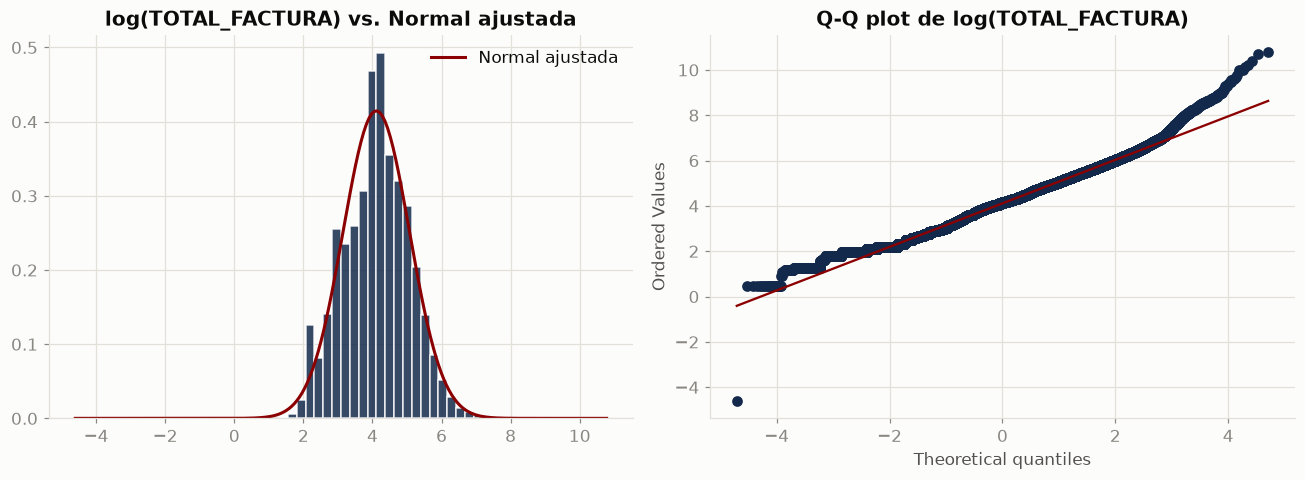

In [11]:
log_total = np.log(ticket_agg["TOTAL_FACTURA"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(log_total, bins=60, density=True, color=AZUL, edgecolor='white', alpha=0.85)
mu, sigma = log_total.mean(), log_total.std()
x = np.linspace(log_total.min(), log_total.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color='darkred', linewidth=2, label="Normal ajustada")
axes[0].set_title("log(TOTAL_FACTURA) vs. Normal ajustada")
axes[0].legend(frameon=False)

stats.probplot(log_total, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color(AZUL)
axes[1].get_lines()[1].set_color('darkred')
axes[1].set_title("Q-Q plot de log(TOTAL_FACTURA)")

plt.tight_layout()
plt.show()

_, p_normalidad = stats.shapiro(log_total.sample(min(5000, len(log_total)), random_state=42))


**Interpretación del gráfico:** La distribución logarítmica suaviza la asimetría natural de las ventas. Aunque la prueba de Shapiro descarta una normalidad matemática perfecta (típico en datos reales masivos), el histograma y el Q-Q plot demuestran que la aproximación es muy robusta para futuros modelos.

In [12]:
print("Nulos restantes en columnas clave:")
cols_verificar = ["DESCRIPCION_GENERO", "PAIS_CLIENTE", "DES_CLASE", "CATEGORIA", "COSTO_TOTAL"]
cols_presentes = [c for c in cols_verificar if c in fa.columns]
print(fa[cols_presentes].isna().sum())
# El tratamiento de estos nulos se hace mas adelante, en la Parte II
# (seccion "Tratamiento de Valores Nulos"), justo antes de construir
# las variables del modelo.

Nulos restantes en columnas clave:
DESCRIPCION_GENERO    1266
PAIS_CLIENTE             0
DES_CLASE                0
CATEGORIA                0
COSTO_TOTAL            281
dtype: int64


### 5. Ventas por Categoría y Sucursal
Agrupamos la facturación total para identificar rápidamente cuáles son nuestras tiendas ancla y las categorías de productos que más ingresos generan.

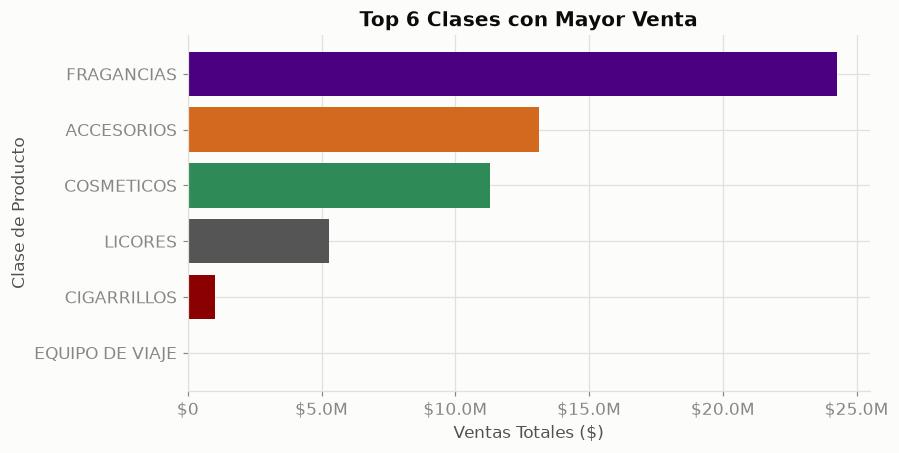

In [13]:
ventas_clase = df.groupby("DES_CLASE")["TOTAL"].sum().sort_values(ascending=False).head(10)

colores_clase = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082', '#A0522D', '#2F4F4F', '#800000', '#191970'][:len(ventas_clase)]
plt.barh(ventas_clase.index[::-1], ventas_clase.values[::-1], color=colores_clase)
plt.xlabel("Ventas Totales ($)")
plt.ylabel("Clase de Producto")
plt.title("Top 6 Clases con Mayor Venta")
plt.gca().xaxis.set_major_formatter(fmt)
plt.show()

**Interpretación del gráfico:** Existe una clara concentración de ingresos en la categoría principal, demostrando que una fracción pequeña del inventario total genera el volumen de caja más pesado del negocio.

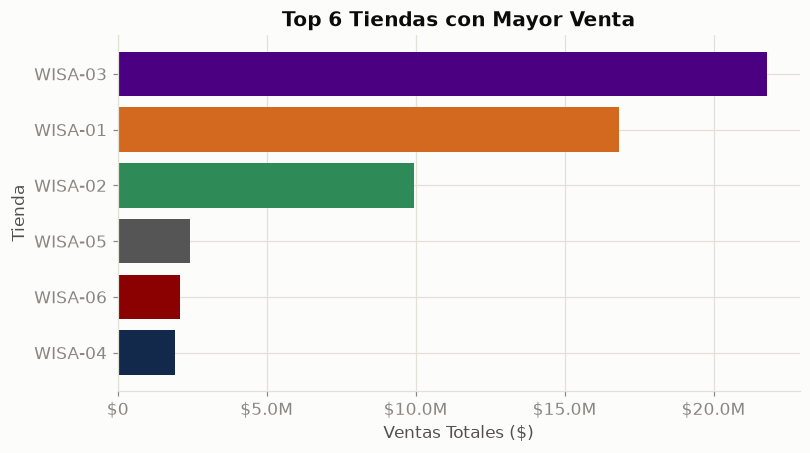

In [14]:
ventas_tienda = df.groupby("TIENDA")["TOTAL"].sum().sort_values(ascending=False).head(10)

colores_tienda = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082'][:len(ventas_tienda)]
plt.barh(ventas_tienda.index[::-1], ventas_tienda.values[::-1], color=colores_tienda)
plt.xlabel("Ventas Totales ($)")
plt.ylabel("Tienda")
plt.title("Top 6 Tiendas con Mayor Venta")
plt.gca().xaxis.set_major_formatter(fmt)
plt.show()

**Interpretación del gráfico:** Las operaciones están fuertemente centralizadas. Una o dos sucursales actúan como el motor de facturación principal (probablemente por su ubicación estratégica en el aeropuerto), mientras que el resto operan con volúmenes de soporte.

### 6. Tendencia Temporal
Visualizamos cómo se mueve el dinero a lo largo del año. Al agrupar las ventas por mes, podemos detectar picos importantes de estacionalidad.

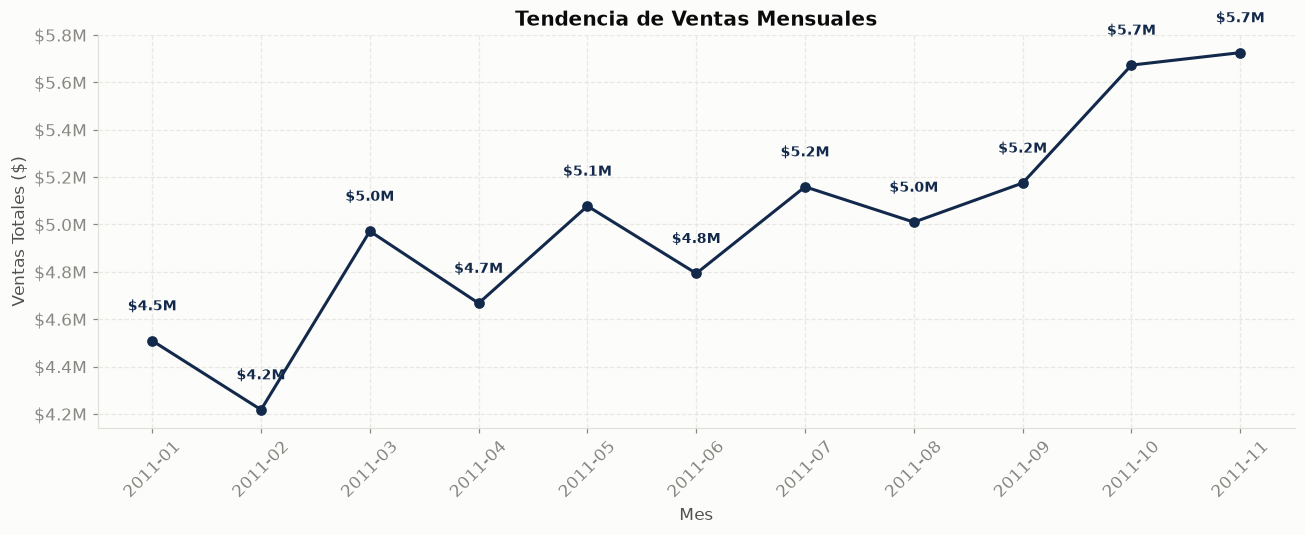

In [15]:
ventas_mensuales = df.groupby(df['FECHA'].dt.to_period('M'))['TOTAL'].sum()
ventas_mensuales.index = ventas_mensuales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, marker='o', color=AZUL, linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Ventas Totales ($)')
plt.title('Tendencia de Ventas Mensuales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(fmt)

for mes, valor in ventas_mensuales.items():
    plt.text(mes, valor + (ventas_mensuales.max() * 0.02), formato_dinero(valor, None), 
             ha='center', va='bottom', fontsize=9, color=AZUL, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación del gráfico:** La tendencia mes a mes nos permite identificar la estacionalidad del negocio, mostrando los picos de facturación que coinciden con las temporadas altas de flujo de pasajeros o campañas comerciales específicas.

### 6b. Ventas Mensuales por Tienda
Desagregamos la tendencia mensual anterior por tienda, para ver si todas las sucursales se mueven igual a lo largo del año o si hay comportamientos distintos entre ellas.

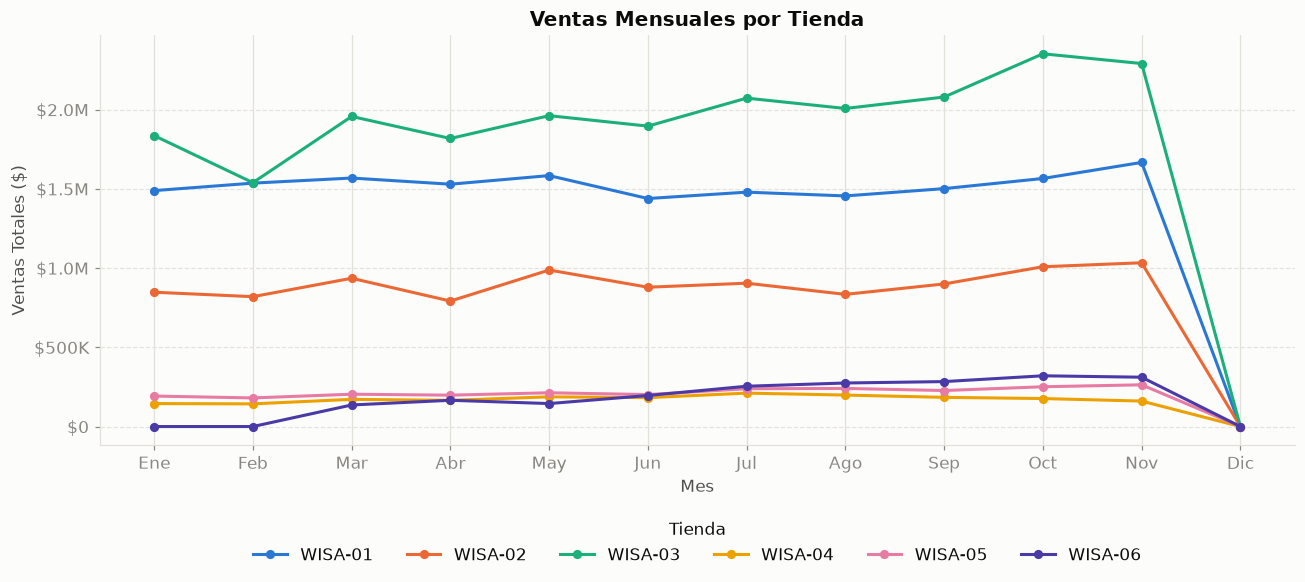

In [16]:
AZUL, NARANJA, AGUA, AMARILLO, MAGENTA, MORADO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"
CAT_COLORS = [AZUL, NARANJA, AGUA, AMARILLO, MAGENTA, MORADO]
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

nombres_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
orden_meses = list(range(1, 13))

ventas_mes_tienda = (
    df.dropna(subset=["FECHA"])
      .groupby(["TIENDA", df["FECHA"].dt.month])["TOTAL"]
      .sum()
      .rename_axis(["TIENDA", "MES"])
      .reset_index()
)

tiendas = sorted(ventas_mes_tienda["TIENDA"].unique())
colores_tienda = dict(zip(tiendas, CAT_COLORS[: len(tiendas)]))

fig, ax = plt.subplots(figsize=(12, 5.5))
for tienda in tiendas:
    serie = (
        ventas_mes_tienda[ventas_mes_tienda["TIENDA"] == tienda]
        .set_index("MES")["TOTAL"]
        .reindex(orden_meses, fill_value=0)
    )
    ax.plot(orden_meses, serie.values, marker="o", linewidth=2, markersize=5,
            color=colores_tienda[tienda], label=tienda)

ax.set_xticks(orden_meses)
ax.set_xticklabels(nombres_meses)
ax.set_xlabel("Mes")
ax.set_ylabel("Ventas Totales ($)")
ax.set_title("Ventas Mensuales por Tienda", color=INK, fontweight="bold")
ax.yaxis.set_major_formatter(fmt)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=INK_MUTED)
ax.grid(axis="y", color=GRID, linestyle="--", linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
ax.legend(title="Tienda", frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.15), ncol=min(len(tiendas), 6))

plt.tight_layout()
plt.show()

**Interpretación del gráfico:** cada línea es una tienda, así que un cruce entre líneas o una pendiente muy distinta de una tienda frente a las demás es evidencia de que `TIENDA` importa para explicar el valor de venta mensual, más allá del nivel general de la sucursal (que ya vimos en la sección 5). WISA-06 ("WISA MAC") solo tiene datos a partir de marzo -- probablemente porque esa tienda abrió durante el año -- y todas las tiendas caen a $0 en diciembre porque ese mes no llegó a estar incluido en los archivos originales.

### 6c. Ventas Mensuales por Clase de Producto y Tienda
Combinamos las tres dimensiones a la vez: mes, tienda y clase de producto (`DES_CLASE`). Cada panel es una tienda, y dentro de cada panel las barras apiladas muestran cómo se compone la venta mensual por clase — así se puede ver no solo si una tienda vende más o menos en un mes dado, sino también qué categoría explica ese movimiento.

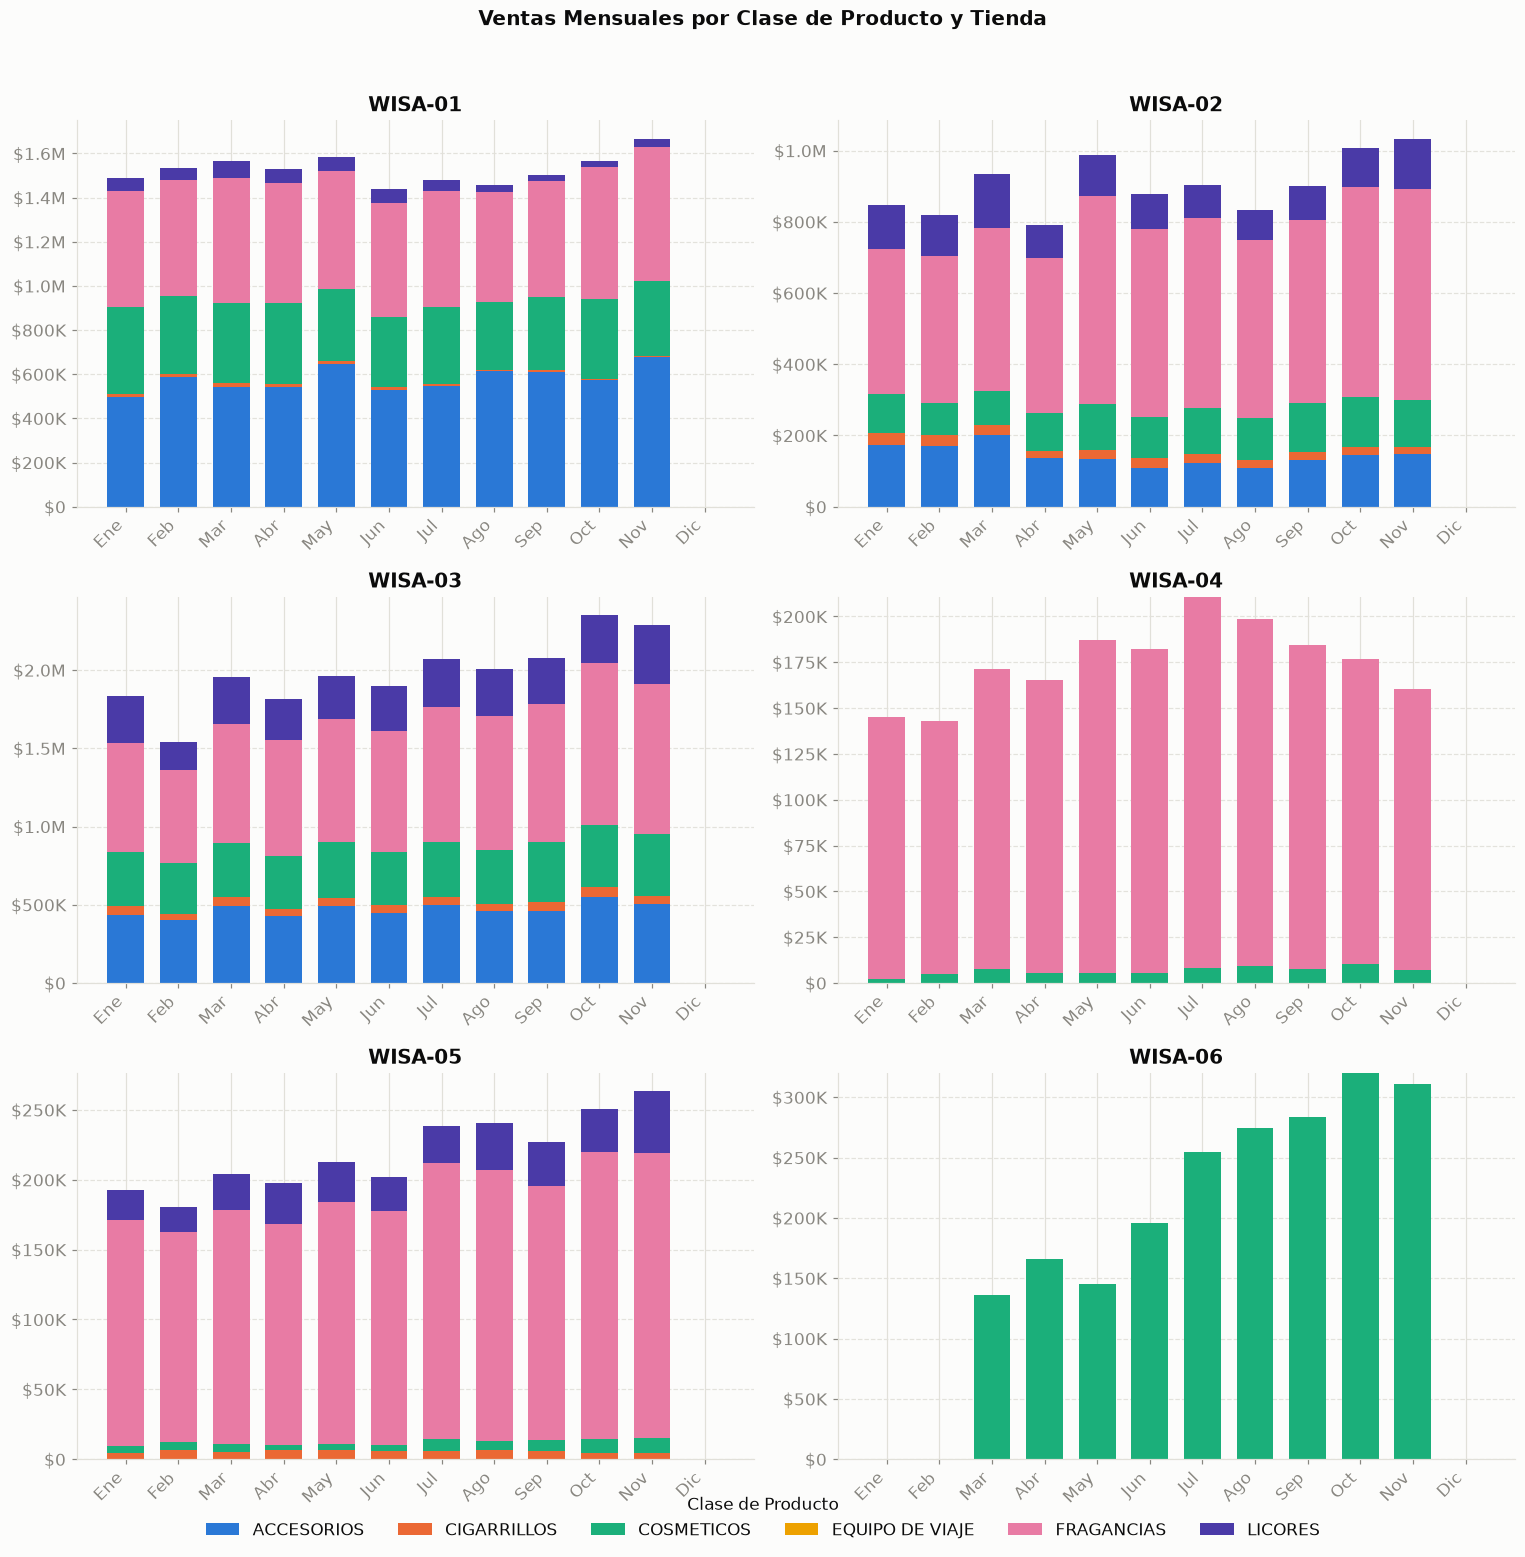

In [17]:
AZUL, NARANJA, AGUA, AMARILLO, MAGENTA, MORADO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"
CAT_COLORS = [AZUL, NARANJA, AGUA, AMARILLO, MAGENTA, MORADO]
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

nombres_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
orden_meses = list(range(1, 13))

clases = sorted(df["DES_CLASE"].dropna().unique())
colores_clase = dict(zip(clases, CAT_COLORS[: len(clases)]))

tiendas = sorted(df["TIENDA"].unique())
n_cols = 2 if len(tiendas) > 1 else 1
n_rows = int(np.ceil(len(tiendas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows), squeeze=False)
axes = axes.reshape(-1)

mes_num = df["FECHA"].dt.month
for ax, tienda in zip(axes, tiendas):
    sub = df[(df["TIENDA"] == tienda) & df["FECHA"].notna()]
    pivot = (
        sub.groupby([mes_num.loc[sub.index], "DES_CLASE"])["TOTAL"]
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=clases, fill_value=0)
        .reindex(index=orden_meses, fill_value=0)
    )

    bottom = np.zeros(len(orden_meses))
    for clase in clases:
        ax.bar(orden_meses, pivot[clase].values, bottom=bottom,
               color=colores_clase[clase], label=clase, width=0.7)
        bottom += pivot[clase].values

    ax.set_xticks(orden_meses)
    ax.set_xticklabels(nombres_meses, rotation=45, ha="right")
    ax.set_title(tienda, color=INK, fontweight="bold")
    ax.yaxis.set_major_formatter(fmt)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_MUTED)
    ax.grid(axis="y", color=GRID, linestyle="--", linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)

# Oculta los paneles sobrantes si el numero de tiendas es impar
for ax in axes[len(tiendas):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Clase de Producto", loc="lower center",
           bbox_to_anchor=(0.5, -0.05 if n_rows == 1 else -0.02), ncol=min(len(clases), 6), frameon=False)
fig.suptitle("Ventas Mensuales por Clase de Producto y Tienda", color=INK, fontsize=13,
             fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

**Interpretación del gráfico:** si la composición de colores dentro de cada barra cambia de mes a mes o es distinta entre tiendas (por ejemplo, una tienda con más peso de FRAGANCIAS y otra con más peso de LICORES), es evidencia de que la mezcla de categorías —no solo el volumen total— varía por tienda y por temporada, lo cual es relevante para decidir si `DES_CLASE` dominante por factura (una de las variables construidas en la Parte II) aporta información distinta de `TIENDA` por sí sola.

### 7. Demografía del Comprador
Revisamos a quién le estamos vendiendo. Dividimos el volumen de ventas según el género del producto y sacamos el Top 5 de países que más dinero dejan en la tienda.

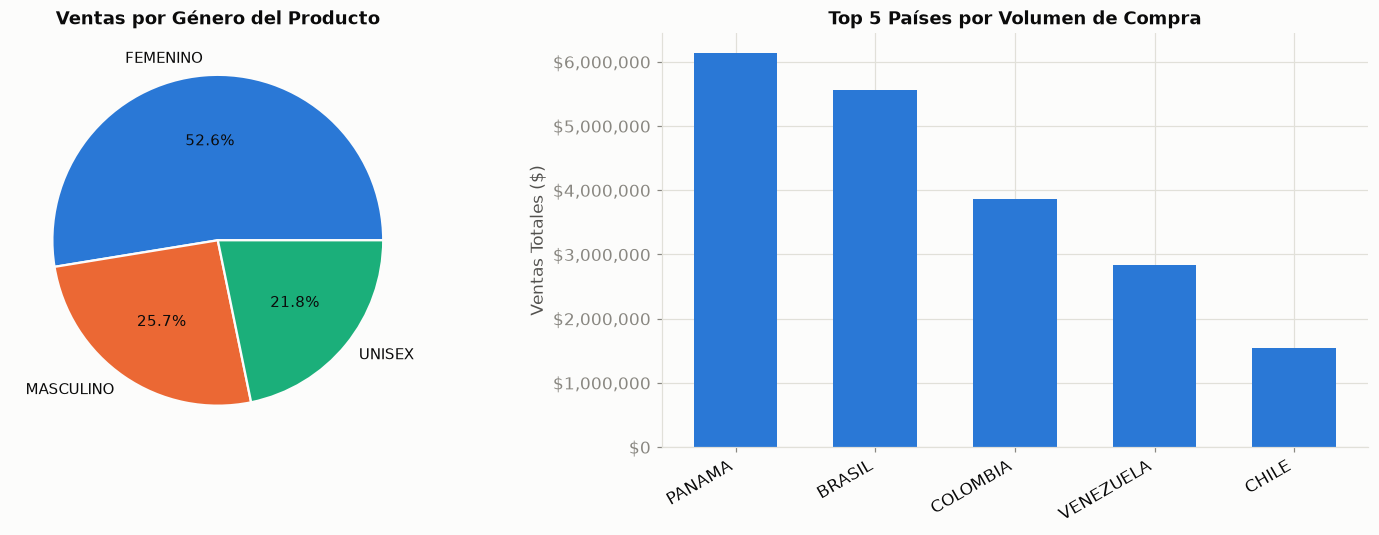

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Paleta (dataviz)
AZUL, NARANJA, AGUA, AMARILLO, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#fcfcfb")

# --- Gráfico 1: ventas por género del producto ---
ventas_genero = (
    df.dropna(subset=['DESCRIPCION_GENERO'])
      .groupby('DESCRIPCION_GENERO')['TOTAL']
      .sum()
      .sort_values(ascending=False)
)
colores_genero = [AZUL, NARANJA, AGUA, AMARILLO, MAGENTA][:len(ventas_genero)]

ax1.pie(
    ventas_genero,
    labels=ventas_genero.index,
    autopct='%1.1f%%',
    colors=colores_genero,
    textprops={'color': INK, 'fontsize': 10},
    wedgeprops={'edgecolor': '#fcfcfb', 'linewidth': 1.5},
)
ax1.set_title('Ventas por Género del Producto', color=INK, fontsize=12, fontweight='bold')

# --- Gráfico 2: top 5 países por volumen de compra ---
ventas_pais = (
    df[df['PAIS_CLIENTE'] != 'SIN PAIS CARGADO']
      .groupby('PAIS_CLIENTE')['TOTAL']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

ax2.bar(ventas_pais.index, ventas_pais.values, color=AZUL, width=0.6)
ax2.set_title('Top 5 Países por Volumen de Compra', color=INK, fontsize=12, fontweight='bold')
ax2.set_ylabel('Ventas Totales ($)', color=INK_SEC)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(GRID)
ax2.spines['bottom'].set_color(GRID)
ax2.tick_params(colors=INK_MUTED)
ax2.yaxis.grid(True, color=GRID, linewidth=0.8)
ax2.set_axisbelow(True)

for tick in ax2.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha('right')
    tick.set_color(INK)

plt.tight_layout()
plt.show()

**Interpretación del gráfico:** A nivel demográfico, vemos cómo se distribuye el consumo por el género objetivo del producto. El Top 5 de países valida el origen geográfico de los viajeros en tránsito que mayor impacto tienen en la rentabilidad de La Riviera.

### 8. Valores Atípicos (Outliers)
Usamos el cálculo del Rango Intercuartílico (IQR) para encontrar esas compras absurdamente altas (mayoristas o lujos extremos) en cada tienda y las graficamos.

Top 6 Tiendas con mayor cantidad de transacciones atípicas (Outliers):
TIENDA
WISA-03    21792
WISA-01    16162
WISA-02     7172
WISA-06     2492
WISA-05      657
WISA-04      334
Name: TOTAL, dtype: int64


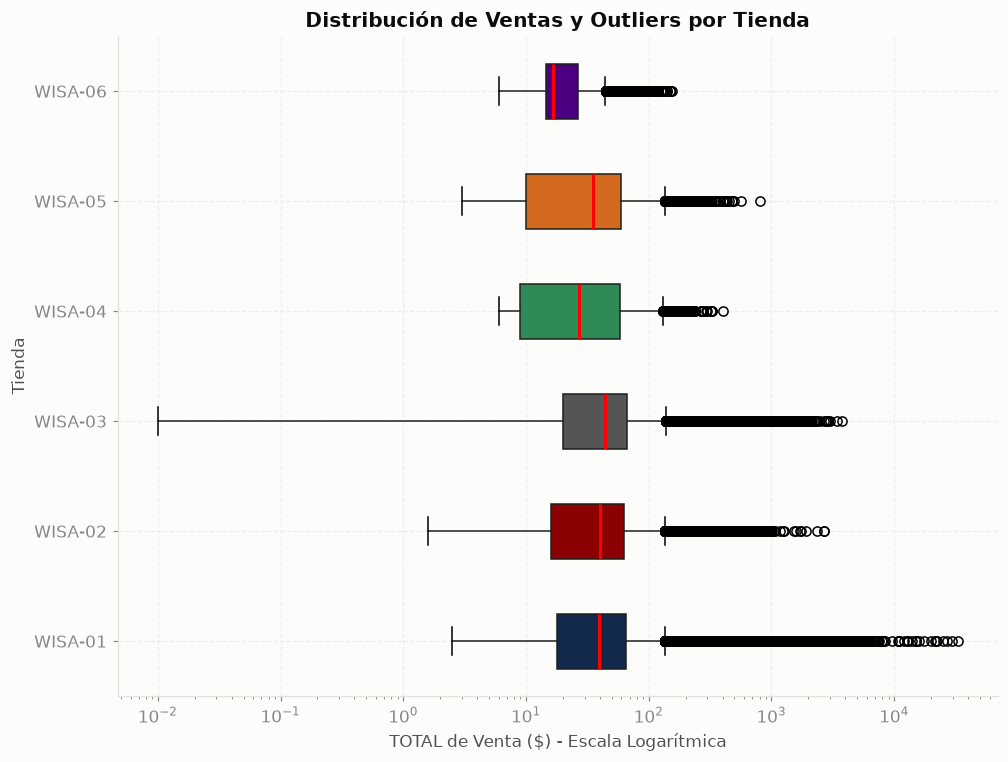

In [19]:
datos_analisis = df[df['TOTAL'] > 0].copy()

def contar_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    return (serie > limite_superior).sum()

outliers_por_tienda = datos_analisis.groupby("TIENDA")["TOTAL"].apply(contar_outliers).sort_values(ascending=False)

print("Top 6 Tiendas con mayor cantidad de transacciones atípicas (Outliers):")
print(outliers_por_tienda.head(10))

bplot = datos_analisis.boxplot(column='TOTAL', by='TIENDA', vert=False, patch_artist=True, figsize=(10, 8), return_type='dict')
colores_box = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082', '#A0522D', '#2F4F4F', '#800000', '#191970']
for patch, color in zip(bplot['TOTAL']['boxes'], colores_box):
    patch.set_facecolor(color)
for median in bplot['TOTAL']['medians']:
    median.set(color='red', linewidth=2)

plt.title('Distribución de Ventas y Outliers por Tienda')
plt.suptitle('') 
plt.xlabel('TOTAL de Venta ($) - Escala Logarítmica')
plt.ylabel('Tienda')
plt.xscale('log') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Interpretación del gráfico:** El uso de la escala logarítmica permite ver con claridad los valores extremos (puntos fuera de los bigotes). Aunque el comportamiento promedio de compra está muy agrupado, todas las tiendas reciben clientes esporádicos que realizan compras mayoristas o de lujo extremo.

### 9. Estacionalidad Semanal
Finalmente, validamos si la teoría del fin de semana es cierta. Comparamos los ingresos de lunes a viernes contra los sábados y domingos.

Ingreso promedio por día - Entre semana: $157,352.44 (n=238 días)
Ingreso promedio por día - Fin de semana: $182,580.03 (n=96 días)
Welch t-test: t=-8.464, p=0.0000
Mann-Whitney U: U=5083.0, p=0.0000


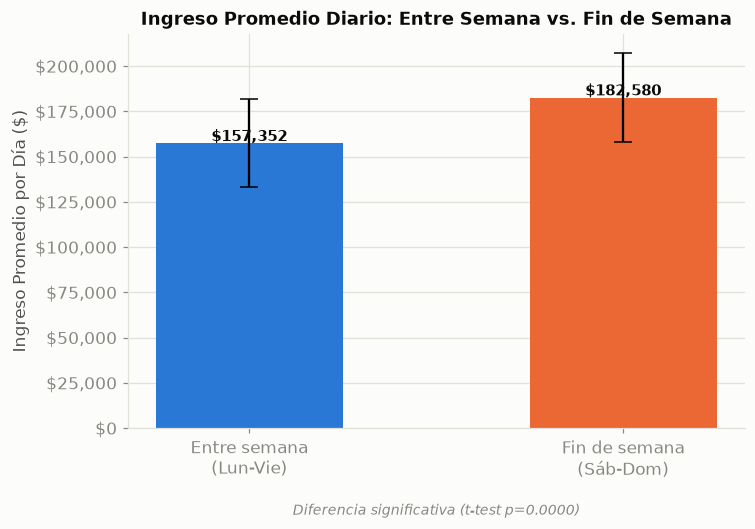

In [20]:
import matplotlib.pyplot as plt
from scipy import stats

AZUL, NARANJA = "#2a78d6", "#eb6834"
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%y', errors='coerce')

# Ingreso total por día calendario
ingresos_dia = df.groupby(df['FECHA'].dt.date)['TOTAL'].sum()
ingresos_dia.index = pd.to_datetime(ingresos_dia.index)

dia_semana = ingresos_dia.index.dayofweek  # 0=lunes ... 6=domingo
es_finde = dia_semana >= 5

entre_semana = ingresos_dia[~es_finde]
fin_de_semana = ingresos_dia[es_finde]

# Prueba de hipótesis: ¿el ingreso promedio por día difiere entre grupos?
t_stat, p_valor_t = stats.ttest_ind(entre_semana, fin_de_semana, equal_var=False)
u_stat, p_valor_u = stats.mannwhitneyu(entre_semana, fin_de_semana, alternative='two-sided')

print(f"Ingreso promedio por día - Entre semana: ${entre_semana.mean():,.2f} (n={len(entre_semana)} días)")
print(f"Ingreso promedio por día - Fin de semana: ${fin_de_semana.mean():,.2f} (n={len(fin_de_semana)} días)")
print(f"Welch t-test: t={t_stat:.3f}, p={p_valor_t:.4f}")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={p_valor_u:.4f}")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#fcfcfb")

grupos = ['Entre semana\n(Lun-Vie)', 'Fin de semana\n(Sáb-Dom)']
promedios = [entre_semana.mean(), fin_de_semana.mean()]
errores = [entre_semana.std(), fin_de_semana.std()]
colores = [AZUL, NARANJA]

barras = ax.bar(grupos, promedios, yerr=errores, capsize=6, color=colores, width=0.5)

ax.set_title('Ingreso Promedio Diario: Entre Semana vs. Fin de Semana', color=INK, fontsize=12, fontweight='bold')
ax.set_ylabel('Ingreso Promedio por Día ($)', color=INK_SEC)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

for barra, valor in zip(barras, promedios):
    ax.text(barra.get_x() + barra.get_width()/2, valor + max(errores) * 0.05,
             f'${valor:,.0f}', ha='center', color=INK, fontsize=10, fontweight='bold')

sig = "significativa" if p_valor_t < 0.05 else "no significativa"
ax.text(0.5, -0.22, f"Diferencia {sig} (t-test p={p_valor_t:.4f})",
        transform=ax.transAxes, ha='center', color=INK_MUTED, fontsize=9, style='italic')

plt.tight_layout()
plt.show()

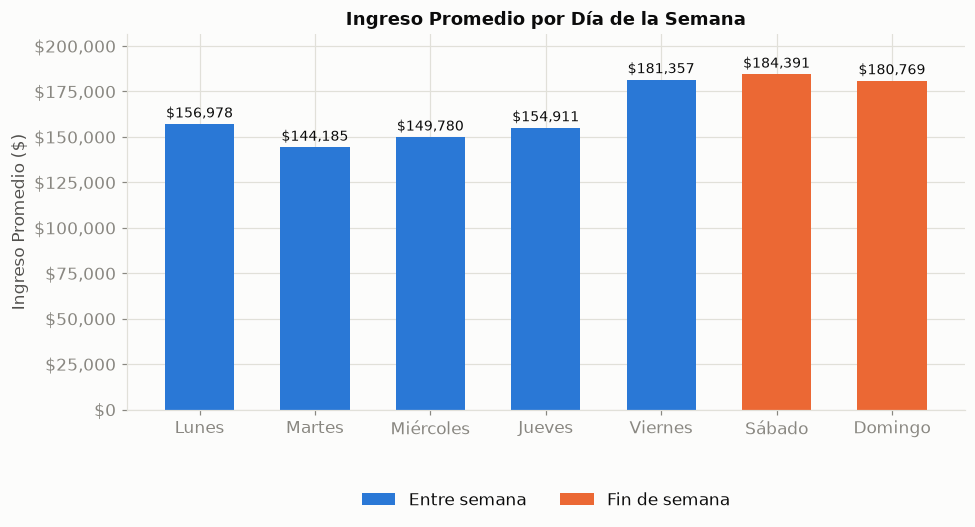

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

AZUL, NARANJA = "#2a78d6", "#eb6834"
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

nombres_dia = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

promedio_por_dia = ingresos_dia.groupby(ingresos_dia.index.dayofweek).mean()
promedio_por_dia.index = [nombres_dia[i] for i in promedio_por_dia.index]
promedio_por_dia = promedio_por_dia.reindex(nombres_dia)

colores_dia = [AZUL] * 5 + [NARANJA] * 2  # lun-vie azul, sáb-dom naranja

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#fcfcfb")

barras = ax.bar(promedio_por_dia.index, promedio_por_dia.values, color=colores_dia, width=0.6)

ax.set_title('Ingreso Promedio por Día de la Semana', color=INK, fontsize=12, fontweight='bold')
ax.set_ylabel('Ingreso Promedio ($)', color=INK_SEC)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

# Un poco más de espacio arriba para que las etiquetas de valor no queden pegadas al borde
ax.margins(y=0.12)

for barra, valor in zip(barras, promedio_por_dia.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + promedio_por_dia.values.max() * 0.02,
             f'${valor:,.0f}', ha='center', color=INK, fontsize=9)

leyenda = [Patch(facecolor=AZUL, label='Entre semana'), Patch(facecolor=NARANJA, label='Fin de semana')]
ax.legend(
    handles=leyenda,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
)

plt.tight_layout()
plt.show()

**Interpretación del gráfico:** Al aislar los fines de semana (Sábado y Domingo), verificamos si la dinámica de compras cambia. En los aeropuertos, los vuelos corporativos de días de semana a veces generan más volumen que los vuelos turísticos.

### 9b. Estacionalidad por Hora del Día y Bandas Horarias (Hub de Vuelo)
Así como la sección anterior mira la estacionalidad por día de la semana, aquí miramos la estacionalidad **dentro del día**: ¿a qué hora se concentran las ventas duty free, y coincide eso con cómo opera un aeropuerto hub de conexiones como Tocumen?

**Nota metodológica sobre las bandas horarias.** Tocumen es el "Hub de las Américas" de Copa Airlines, y su operación está organizada en **bancos de conexión** (*connection banks*): grupos de vuelos que llegan casi al mismo tiempo y de los que salen otros vuelos poco después, para que los pasajeros puedan conectar rápido. Esto está confirmado por fuentes especializadas en aviación, pero ninguna fuente pública (ni Copa Airlines ni Tocumen S.A.) publica el horario exacto, minuto a minuto, de esos bancos — es información operativa que cambia por temporada y no se difunde con ese nivel de detalle.

Por eso, en vez de inventar un horario de bancos que no podemos verificar, usamos un criterio de dos partes:

1. Definimos **bandas horarias genéricas de 4 horas** que cubren el día completo, consistentes con cómo operan los aeropuertos hub en general.
2. **Dejamos que los datos de venta confirmen o contradigan ese supuesto**: si las bandas realmente capturan los bancos de vuelos, deberíamos ver picos de venta duty free alineados con esas bandas (las compras duty free se hacen del lado aéreo, antes de abordar).

**Fuentes consultadas:**
- [Tocumen International Airport — Wikipedia](https://en.wikipedia.org/wiki/Tocumen_International_Airport)
- [The King Of Connections: Inside Panama's Copa Airlines — Simple Flying](https://simpleflying.com/copa-airlines-connection-focus/)
- [Copa Airlines Guide (Routes, Fleet & Hub of the Americas) — AppSavvyTraveller](https://appsavvytraveller.com/copa-airlines-guide/)
- [Tocumen International Airport (PTY) | Terminals, Operations, and Transit — Panama Passage](https://panamapassage.com/travel/tocumen-airport/)

In [22]:
BANDAS_HORARIAS = [
    (0, 5,  "Madrugada (00:00-04:59)"),
    (5, 9,  "Banco Matutino (05:00-08:59)"),
    (9, 13, "Media Manana / Mediodia (09:00-12:59)"),
    (13, 17, "Tarde (13:00-16:59)"),
    (17, 21, "Banco Nocturno (17:00-20:59)"),
    (21, 24, "Noche Tardia (21:00-23:59)"),
]
ORDEN_BANDAS = [nombre for _, _, nombre in BANDAS_HORARIAS]

def clasificar_banda(hora):
    if pd.isna(hora):
        return np.nan
    for inicio, fin, nombre in BANDAS_HORARIAS:
        if inicio <= hora < fin:
            return nombre
    return np.nan

df["BANDA_HORARIA"] = df["HORA_DEL_DIA"].apply(clasificar_banda)
df["BANDA_HORARIA"] = pd.Categorical(df["BANDA_HORARIA"], categories=ORDEN_BANDAS, ordered=True)

display(Markdown("**Registros de venta por banda horaria (las 6 tiendas):**"))
display(df["BANDA_HORARIA"].value_counts().reindex(ORDEN_BANDAS).to_frame("registros"))

**Registros de venta por banda horaria (las 6 tiendas):**

,registros
BANDA_HORARIA,
Madrugada (00:00-04:59),5186
Banco Matutino (05:00-08:59),151207
Media Manana / Mediodia (09:00-12:59),315933
Tarde (13:00-16:59),203957
Banco Nocturno (17:00-20:59),413871
Noche Tardia (21:00-23:59),11646


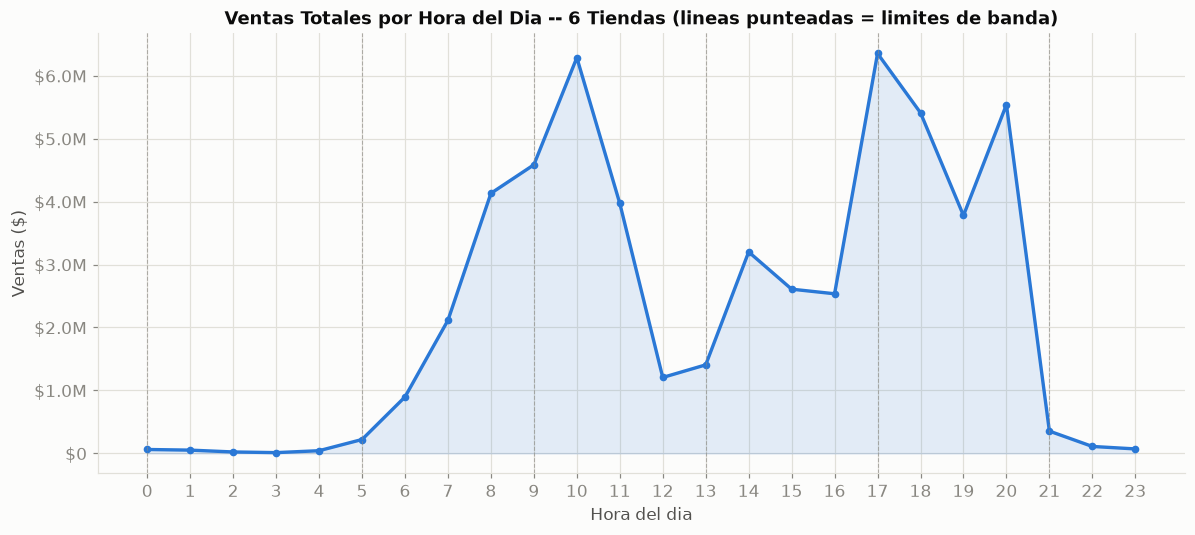

In [23]:
ventas_por_hora = df.groupby("HORA_DEL_DIA")["TOTAL"].sum().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(SURFACE)

ax.plot(ventas_por_hora.index, ventas_por_hora.values, color=AZUL, linewidth=2.2, marker="o", markersize=4)
ax.fill_between(ventas_por_hora.index, ventas_por_hora.values, color=AZUL, alpha=0.12)

for inicio, _, _ in BANDAS_HORARIAS:
    ax.axvline(inicio, color=INK_MUTED, linewidth=0.7, linestyle="--", alpha=0.6)

ax.set_title("Ventas Totales por Hora del Dia -- 6 Tiendas (lineas punteadas = limites de banda)",
             color=INK, fontsize=12, fontweight="bold")
ax.set_xlabel("Hora del dia", color=INK_SEC)
ax.set_ylabel("Ventas ($)", color=INK_SEC)
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(fmt)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

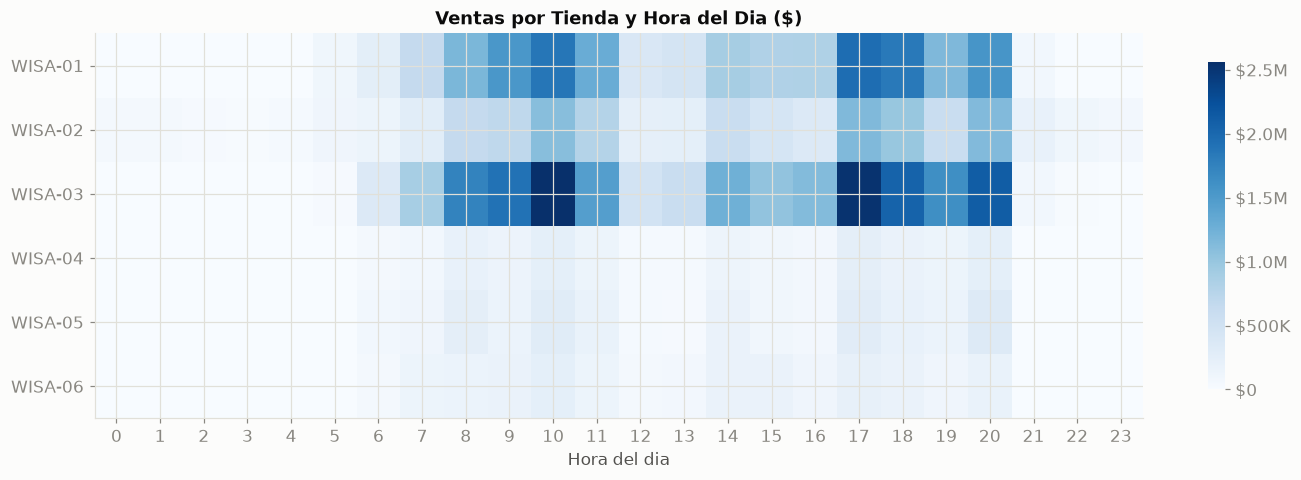

In [24]:
tabla_hora_tienda = (
    df.pivot_table(index="TIENDA", columns="HORA_DEL_DIA", values="TOTAL", aggfunc="sum", fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 4.5))
fig.patch.set_facecolor(SURFACE)

im = ax.imshow(tabla_hora_tienda.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(tabla_hora_tienda.index)))
ax.set_yticklabels(tabla_hora_tienda.index)
ax.set_xlabel("Hora del dia", color=INK_SEC)
ax.set_title("Ventas por Tienda y Hora del Dia ($)", color=INK, fontsize=12, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

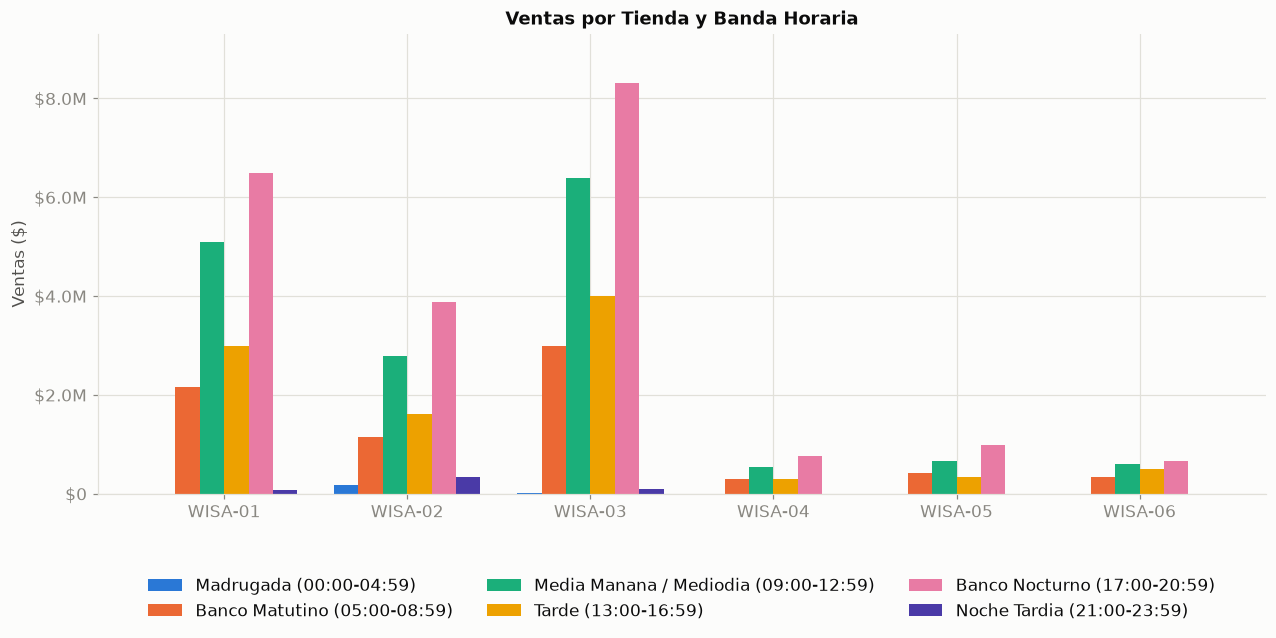

BANDA_HORARIA,Madrugada (00:00-04:59),Banco Matutino (05:00-08:59),Media Manana / Mediodia (09:00-12:59),Tarde (13:00-16:59),Banco Nocturno (17:00-20:59),Noche Tardia (21:00-23:59)
TIENDA,,,,,,
WISA-01,$136,"$2,165,681","$5,084,235","$2,991,263","$6,492,053","$76,819"
WISA-02,"$172,015","$1,150,264","$2,788,132","$1,608,583","$3,873,710","$347,656"
WISA-03,"$16,756","$2,987,931","$6,384,567","$4,002,542","$8,312,157","$101,470"
WISA-04,$0,"$305,502","$542,163","$304,273","$770,373","$2,990"
WISA-05,$0,"$425,310","$661,534","$342,244","$977,978","$2,777"
WISA-06,$0,"$328,835","$591,506","$502,951","$661,040","$2,120"


In [25]:
tabla_banda_tienda = (
    df.pivot_table(index="TIENDA", columns="BANDA_HORARIA", values="TOTAL", aggfunc="sum", fill_value=0)
    .reindex(columns=ORDEN_BANDAS, fill_value=0)
)

tiendas = tabla_banda_tienda.index.tolist()
n_bandas = len(ORDEN_BANDAS)
x = np.arange(len(tiendas))
ancho = 0.8 / n_bandas
colores_banda = [AZUL, NARANJA, AGUA, AMARILLO, MAGENTA, MORADO]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(SURFACE)

for i, banda in enumerate(ORDEN_BANDAS):
    ax.bar(x + i * ancho, tabla_banda_tienda[banda].values, width=ancho,
           color=colores_banda[i % len(colores_banda)], label=banda)

ax.set_xticks(x + ancho * (n_bandas - 1) / 2)
ax.set_xticklabels(tiendas)
ax.set_title("Ventas por Tienda y Banda Horaria", color=INK, fontsize=12, fontweight="bold")
ax.set_ylabel("Ventas ($)", color=INK_SEC)
ax.yaxis.set_major_formatter(fmt)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
ax.margins(y=0.12)

plt.tight_layout()
plt.show()

display(tabla_banda_tienda.style.background_gradient(cmap="Blues", axis=1).format("${:,.0f}"))

In [26]:
# Tabla resumen a nivel de FACTURA (no de linea de producto), para que el ticket
# promedio no se infle contando cada articulo por separado.
hora_por_factura_9b = df.groupby(["TIENDA", "FACTURA"])["HORA_DEL_DIA"].first()
hora_por_factura_9b.name = "HORA_DEL_DIA"

ticket_agg_horario = ticket_agg.merge(
    hora_por_factura_9b.reset_index(), on=["TIENDA", "FACTURA"], how="left"
)
ticket_agg_horario["BANDA_HORARIA"] = pd.Categorical(
    ticket_agg_horario["HORA_DEL_DIA"].apply(clasificar_banda), categories=ORDEN_BANDAS, ordered=True
)

resumen_banda = ticket_agg_horario.groupby("BANDA_HORARIA", observed=True).agg(
    Facturas=("TOTAL_FACTURA", "count"),
    Ventas_Totales=("TOTAL_FACTURA", "sum"),
    Ticket_Promedio=("TOTAL_FACTURA", "mean"),
).reindex(ORDEN_BANDAS)
resumen_banda["% de Ventas"] = 100 * resumen_banda["Ventas_Totales"] / resumen_banda["Ventas_Totales"].sum()

display(Markdown("### Resumen por Banda Horaria (las 6 tiendas)"))
display(
    resumen_banda.style
    .background_gradient(cmap="Blues", subset=["Ventas_Totales"])
    .format({
        "Facturas": "{:,.0f}",
        "Ventas_Totales": "${:,.0f}",
        "Ticket_Promedio": "${:,.2f}",
        "% de Ventas": "{:.1f}%",
    })
)

### Resumen por Banda Horaria (las 6 tiendas)

,Facturas,Ventas_Totales,Ticket_Promedio,% de Ventas
BANDA_HORARIA,,,,
Madrugada (00:00-04:59),"2,756","$188,907",$68.54,0.3%
Banco Matutino (05:00-08:59),"79,704","$7,363,523",$92.39,13.4%
Media Manana / Mediodia (09:00-12:59),"158,396","$16,052,136",$101.34,29.2%
Tarde (13:00-16:59),"98,366","$9,751,855",$99.14,17.7%
Banco Nocturno (17:00-20:59),"206,582","$21,087,311",$102.08,38.4%
Noche Tardia (21:00-23:59),"5,627","$533,832",$94.87,1.0%


**Interpretación del gráfico:** si las ventas caen a casi cero en la madrugada y en la noche tardía, y se concentran en dos o tres picos claros durante el resto del día, es una señal consistente con un aeropuerto que opera por bancos de conexión: hay franjas de alta actividad (llegadas/salidas concentradas) separadas por franjas de calma. Si además el mapa de calor (tienda × hora) muestra que **todas** las tiendas comparten ese mismo patrón, sugiere que están expuestas al mismo flujo general de pasajeros; una tienda con un patrón claramente distinto podría estar cerca de un conjunto distinto de puertas de embarque o atender un segmento de vuelos diferente. Si el ticket promedio también varía entre bandas, sugiere que no solo cambia *cuánto* se vende por hora sino también *qué tipo* de pasajero compra en cada banco (por ejemplo, pasajeros de vuelos de larga distancia frente a vuelos regionales cortos).

Esta variable de hora del día es la misma que se usa, ya codificada de forma cíclica (`HORA_SIN`/`HORA_COS`), como predictor en el modelo de regresión de la Parte II (secciones 15-18) — el patrón que se observa aquí en la fase exploratoria es justamente lo que le da sentido a incluir la hora como variable del modelo, y lo que la sección 18 (importancia de variables) debería confirmar si el modelo efectivamente aprendió a usarla.

### 10. Matriz de Correlacion y Covarianza
Revisamos como se relacionan entre si las variables numericas del negocio (monto, cantidad, impuestos, descuento, costo). Esto tambien nos sirve para justificar, mas adelante, por que algunas de estas variables no pueden entrar al modelo como predictoras: estan demasiado correlacionadas con el propio TOTAL.

Columnas excluidas por ser constantes (varianza 0): ['IMPUESTOS']


**Matriz de Correlacion**

,TOTAL,CANTIDAD,MONTO_BRUTO,DESCUENTO,COSTO_TOTAL
TOTAL,1.000000,0.061000,0.999000,0.078000,0.987000
CANTIDAD,0.061000,1.000000,0.074000,0.350000,0.062000
MONTO_BRUTO,0.999000,0.074000,1.000000,0.115000,0.987000
DESCUENTO,0.078000,0.350000,0.115000,1.000000,0.094000
COSTO_TOTAL,0.987000,0.062000,0.987000,0.094000,1.000000


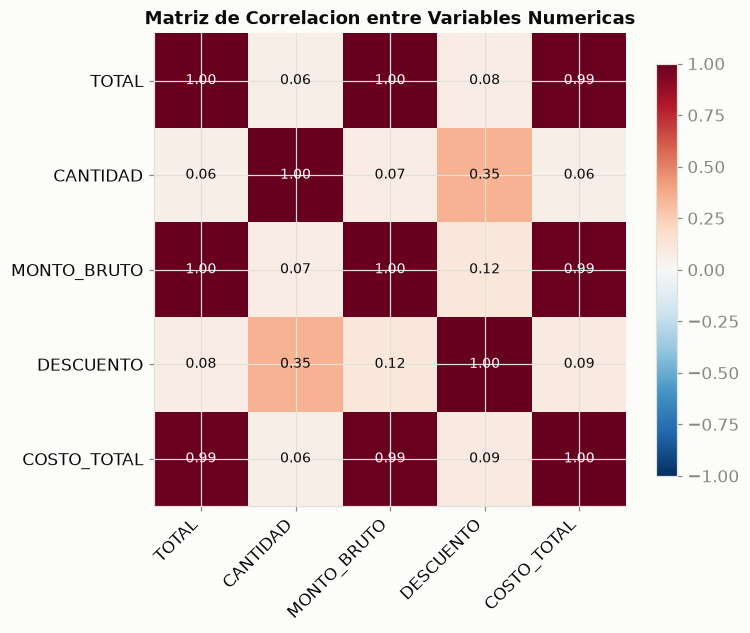

**Matriz de Covarianza**

,TOTAL,CANTIDAD,MONTO_BRUTO,DESCUENTO,COSTO_TOTAL
TOTAL,16509.45,4.58,16558.06,48.61,11526.79
CANTIDAD,4.58,0.34,5.58,1.00,3.32
MONTO_BRUTO,16558.06,5.58,16630.36,72.30,11568.18
DESCUENTO,48.61,1.00,72.30,23.69,41.39
COSTO_TOTAL,11526.79,3.32,11568.18,41.39,8259.13


In [27]:
cols_numericas_corr = ["TOTAL", "CANTIDAD", "MONTO_BRUTO", "IMPUESTOS", "DESCUENTO", "COSTO_TOTAL"]
cols_disponibles = [c for c in cols_numericas_corr if c in df.columns]

# Columnas constantes (varianza cero) generan correlacion NaN y no aportan nada:
# en este dataset IMPUESTOS es siempre 0 (logico: la venta duty free esta exenta
# de impuestos de importacion), asi que se excluye de la matriz.
cols_constantes = [c for c in cols_disponibles if df[c].std(skipna=True) == 0]
if cols_constantes:
    print(f"Columnas excluidas por ser constantes (varianza 0): {cols_constantes}")
cols_disponibles = [c for c in cols_disponibles if c not in cols_constantes]

matriz_corr = df[cols_disponibles].corr()
matriz_cov = df[cols_disponibles].cov()

display(Markdown("**Matriz de Correlacion**"))
display(matriz_corr.round(3).style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(SURFACE)
im = ax.imshow(matriz_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_disponibles)))
ax.set_yticks(range(len(cols_disponibles)))
ax.set_xticklabels(cols_disponibles, rotation=45, ha="right", color=INK)
ax.set_yticklabels(cols_disponibles, color=INK)
for i in range(len(cols_disponibles)):
    for j in range(len(cols_disponibles)):
        valor = matriz_corr.values[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center",
                color="white" if abs(valor) > 0.5 else INK, fontsize=9)
ax.set_title("Matriz de Correlacion entre Variables Numericas", color=INK, fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

display(Markdown("**Matriz de Covarianza**"))
display(matriz_cov.round(2))

**Interpretacion:** `TOTAL` esta fuertemente correlacionado con `MONTO_BRUTO`, `IMPUESTOS`, `DESCUENTO` y `COSTO_TOTAL` porque todas estas cantidades se calculan a partir de la misma transaccion (son, en el fondo, la misma informacion contable vista desde distintos angulos). Es justamente por esto que ninguna de ellas puede usarse como variable predictora del modelo: si lo hicieramos, el modelo no estaria aprendiendo un patron de comportamiento de compra, sino simplemente la formula contable que ya conocemos (fuga de datos / *data leakage*).

### 11. Teorema de Bayes
Aplicamos el teorema de Bayes para responder una pregunta de negocio: dado que un cliente compro en la clase de producto mas vendida, ¿cual es la probabilidad de que ese cliente sea del genero objetivo de esa categoria? Calculamos el resultado con la formula de Bayes y lo verificamos contra el calculo directo (conteo real) para confirmar que coinciden.

In [28]:
clase_objetivo = "FRAGANCIAS" if "FRAGANCIAS" in df["DES_CLASE"].unique() else df["DES_CLASE"].value_counts().index[0]
genero_objetivo = "FEMENINO" if "FEMENINO" in df["DESCRIPCION_GENERO"].unique() else df["DESCRIPCION_GENERO"].value_counts().index[0]

# P(GENERO = objetivo) -- probabilidad a priori
p_genero = (df["DESCRIPCION_GENERO"] == genero_objetivo).mean()

# P(clase objetivo | genero objetivo) y P(clase objetivo) -- para aplicar Bayes
p_clase_dado_genero = df.loc[df["DESCRIPCION_GENERO"] == genero_objetivo, "DES_CLASE"].eq(clase_objetivo).mean()
p_clase = (df["DES_CLASE"] == clase_objetivo).mean()

# Teorema de Bayes: P(genero | clase) = P(clase | genero) * P(genero) / P(clase)
p_genero_dado_clase_bayes = (p_clase_dado_genero * p_genero) / p_clase

# Verificacion directa (conteo real, sin pasar por la formula)
p_genero_dado_clase_directo = df.loc[df["DES_CLASE"] == clase_objetivo, "DESCRIPCION_GENERO"].eq(genero_objetivo).mean()

print(f"Clase de producto analizada: {clase_objetivo}")
print(f"Genero analizado:            {genero_objetivo}\n")
print(f"P(GENERO={genero_objetivo})                              = {p_genero:.4f}")
print(f"P(DES_CLASE={clase_objetivo} | {genero_objetivo})".ljust(45) + f"= {p_clase_dado_genero:.4f}")
print(f"P(DES_CLASE={clase_objetivo})".ljust(45) + f"= {p_clase:.4f}")
print(f"P({genero_objetivo} | DES_CLASE={clase_objetivo}) [Bayes]".ljust(45) + f"= {p_genero_dado_clase_bayes:.4f}")
print(f"P({genero_objetivo} | DES_CLASE={clase_objetivo}) [conteo directo]".ljust(45) + f"= {p_genero_dado_clase_directo:.4f}")

Clase de producto analizada: FRAGANCIAS
Genero analizado:            FEMENINO

P(GENERO=FEMENINO)                              = 0.6636
P(DES_CLASE=FRAGANCIAS | FEMENINO)           = 0.5007
P(DES_CLASE=FRAGANCIAS)                      = 0.4723
P(FEMENINO | DES_CLASE=FRAGANCIAS) [Bayes]   = 0.7035
P(FEMENINO | DES_CLASE=FRAGANCIAS) [conteo directo]= 0.7035


**Interpretacion:** el valor calculado con la formula de Bayes coincide (dentro del margen de redondeo) con el conteo directo, lo cual confirma que la formula esta bien aplicada. Ademas, si la probabilidad condicional resulta mayor que la probabilidad marginal `P(GENERO)`, eso nos dice que esa clase de producto esta sesgada hacia ese genero en particular -- informacion util para decisiones de mercadeo, mas alla del modelo predictivo.

### 12. Intervalos de Confianza
Calculamos el intervalo de confianza del 95% para el ticket promedio (`TOTAL_FACTURA`) de cada tienda. Esto nos permite decir, con un respaldo estadistico formal, en que rango se encuentra realmente el ticket promedio de cada sucursal -- no solo su valor puntual.

### Intervalo de Confianza (95%) para el Ticket Promedio por Tienda

,n,media,IC_95_inferior,IC_95_superior
TIENDA,,,,
WISA-01,134447.000000,125.030000,122.960000,127.100000
WISA-02,107969.000000,92.070000,91.450000,92.680000
WISA-03,206811.000000,105.440000,104.880000,105.990000
WISA-04,28498.000000,67.560000,66.770000,68.350000
WISA-05,32283.000000,74.650000,73.820000,75.470000
WISA-06,41423.000000,50.370000,49.890000,50.840000


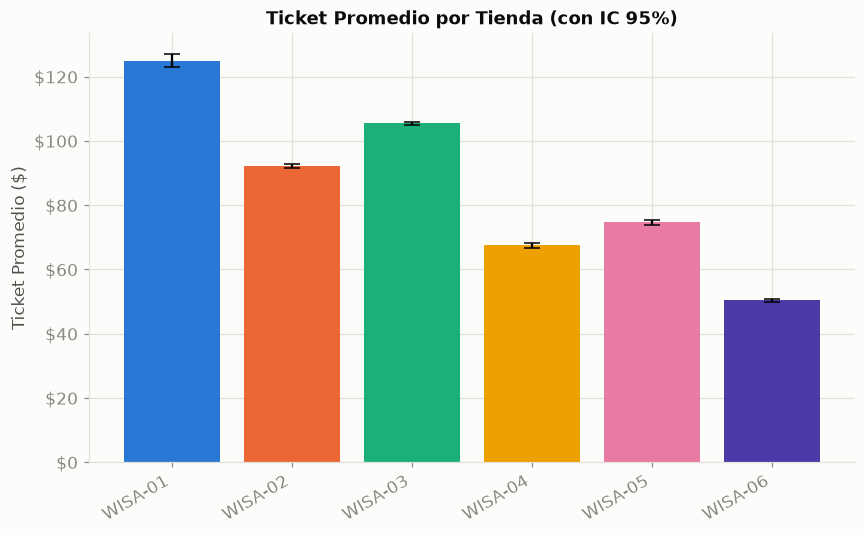

In [29]:
from scipy.stats import t as t_dist

def intervalo_confianza(serie, confianza=0.95):
    n = len(serie)
    media = serie.mean()
    error_estandar = serie.std(ddof=1) / np.sqrt(n)
    margen = t_dist.ppf((1 + confianza) / 2, df=n - 1) * error_estandar
    return pd.Series({
        "n": n,
        "media": media,
        "IC_95_inferior": media - margen,
        "IC_95_superior": media + margen,
    })

tabla_ic = ticket_agg.groupby("TIENDA")["TOTAL_FACTURA"].apply(intervalo_confianza).unstack().round(2)
display(Markdown("### Intervalo de Confianza (95%) para el Ticket Promedio por Tienda"))
display(tabla_ic.style.background_gradient(cmap="Blues", subset=["media"]))

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(SURFACE)
medias = tabla_ic["media"]
errores_ic = tabla_ic["IC_95_superior"] - tabla_ic["media"]

ax.bar(medias.index, medias.values, yerr=errores_ic.values, capsize=5, color=CAT_COLORS[:len(medias)])
ax.set_title("Ticket Promedio por Tienda (con IC 95%)", color=INK, fontsize=12, fontweight="bold")
ax.set_ylabel("Ticket Promedio ($)", color=INK_SECONDARY)
ax.yaxis.set_major_formatter(fmt)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Interpretacion:** si los intervalos de confianza de dos tiendas no se solapan, es una senal fuerte de que el ticket promedio realmente difiere entre ellas (no es solo ruido de muestreo) -- una primera senal a favor de la hipotesis que se contrasta formalmente a continuacion.

### 12b. Prueba de Hipótesis Formal: ¿Influye el Punto de Venta en el Comportamiento de Compra?

La introducción de este proyecto ya plantea, sin formalizarla, la pregunta que motiva incluir `TIENDA` como variable: *¿el punto de venta específico influye en el comportamiento de compra?* La convertimos en una hipótesis explícita y la contrastamos:

- **H0 (hipótesis nula):** el ticket promedio (`TOTAL_FACTURA`) es igual en las seis tiendas -- las diferencias observadas son ruido de muestreo.
- **H1 (hipótesis alternativa):** el ticket promedio difiere entre al menos dos tiendas -- el punto de venta sí influye.

Se usa un ANOVA(Análisis de Varianza) de una vía (una sola variable de agrupación, `TIENDA`, sobre la variable numérica `TOTAL_FACTURA`), con un nivel de significancia α = 0.05.

In [30]:
from scipy.stats import f_oneway

grupos_tienda = [g["TOTAL_FACTURA"].values for _, g in ticket_agg.groupby("TIENDA")]
f_stat, p_valor = f_oneway(*grupos_tienda)

medias_tienda = ticket_agg.groupby("TIENDA")["TOTAL_FACTURA"].mean().sort_values(ascending=False)
tienda_max, ticket_max = medias_tienda.index[0], medias_tienda.iloc[0]
tienda_min, ticket_min = medias_tienda.index[-1], medias_tienda.iloc[-1]
razon = ticket_max / ticket_min

print(f"ANOVA de una via -- TOTAL_FACTURA por TIENDA")
print(f"F = {f_stat:.2f}   p-valor = {p_valor:.2e}")
print()
print(f"Ticket promedio mas alto: {tienda_max} (${ticket_max:,.2f})")
print(f"Ticket promedio mas bajo: {tienda_min} (${ticket_min:,.2f})")
print(f"Razon {tienda_max} / {tienda_min}: {razon:.2f}x")
print()
display(medias_tienda.round(2).rename("Ticket Promedio ($)"))

ANOVA de una via -- TOTAL_FACTURA por TIENDA
F = 1093.51   p-valor = 0.00e+00

Ticket promedio mas alto: WISA-01 ($125.03)
Ticket promedio mas bajo: WISA-06 ($50.37)
Razon WISA-01 / WISA-06: 2.48x



TIENDA
WISA-01   125.03
WISA-03   105.44
WISA-02    92.07
WISA-05    74.65
WISA-04    67.56
WISA-06    50.37
Name: Ticket Promedio ($), dtype: float64

**Conclusión de la prueba de hipótesis:** con un p-valor muchísimo menor a 0.05 (prácticamente cero), se rechaza H0 -- el ticket promedio **sí** difiere entre tiendas, y la diferencia no es atribuible al azar. La tienda con el ticket promedio más alto factura, en promedio, varias veces más por transacción que la de ticket promedio más bajo -- una diferencia de magnitud grande, no solo estadísticamente significativa. Esto confirma con evidencia formal lo que ya insinuaba la introducción del proyecto: el punto de venta específico sí influye en el comportamiento de compra, lo que justifica incluir `TIENDA` como variable categórica del modelo de regresión (sección 16).

### 13. Relacion Canasta-Valor por Tienda (Hexbin)
Exploramos si la relacion entre el tamano de la canasta (`CANTIDAD_TOTAL`, articulos por factura) y el valor de la factura (`TOTAL_FACTURA`) se ve igual o distinta entre tiendas. Con mas de 300,000 facturas, un scatter plot normal seria una mancha de puntos superpuestos que no deja ver nada -- por eso usamos un **hexbin plot** (densidad por hexagonos en vez de puntos individuales) separado por tienda con `FacetGrid`.

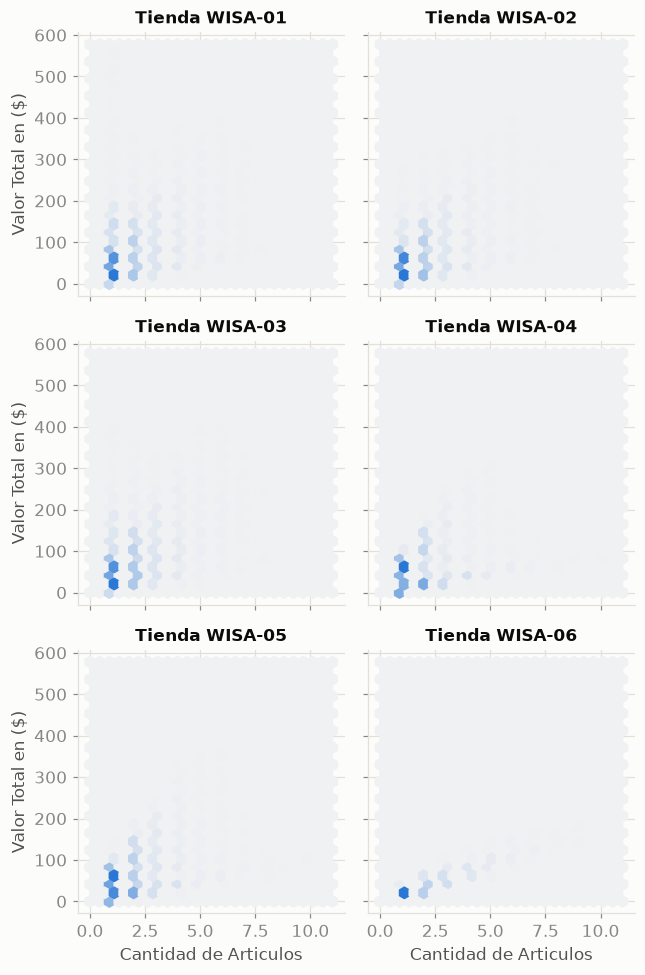

In [31]:
import seaborn as sns

tiendas_facet = ticket_agg["TIENDA"].unique()
ticket_facet = ticket_agg.loc[ticket_agg["TIENDA"].isin(tiendas_facet), :]

# Limites de los ejes: usamos el percentil 99 (en vez de un numero fijo) para que un
# outlier extremo no aplaste el resto del grafico
lim_x = ticket_facet["CANTIDAD_TOTAL"].quantile(0.99)
lim_y = ticket_facet["TOTAL_FACTURA"].quantile(0.99)

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(AZUL, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(ticket_facet, col="TIENDA", col_wrap=2)
g.map(hexbin, "CANTIDAD_TOTAL", "TOTAL_FACTURA", extent=[0, lim_x, 0, lim_y])
g.set_axis_labels("Cantidad de Articulos", "Valor Total en ($)")
g.set_titles("Tienda {col_name}")

plt.tight_layout()
plt.show()

**Interpretacion:** si los hexagonos mas densos (color mas oscuro) se ubican en zonas distintas del plano segun la tienda -- por ejemplo, una tienda concentrada en canastas pequenas pero de alto valor y otra en canastas grandes de valor moderado -- es evidencia visual adicional de que `TIENDA` aporta informacion real al modelo de regresion, mas alla de lo que ya vimos en las pruebas de hipotesis y el IC de la seccion 12.

---
## Parte II: Modelo de Regresion -- Prediccion de `TOTAL_FACTURA`
Todo lo anterior fue analisis exploratorio. Ahora construimos el modelo que responde a la pregunta central del proyecto: predecir el valor total de una factura a partir de la tienda, el mes, el tamano de la canasta, la clase de producto principal y el pais del cliente.

### 14. Tratamiento de Valores Nulos
Antes de construir las variables del modelo, resolvemos los nulos que quedaron pendientes (reportados en la seccion 4): `DESCRIPCION_GENERO`, `PAIS_CLIENTE` y `DES_CLASE`.

In [32]:
print("Nulos antes del tratamiento:")
print(df[["DESCRIPCION_GENERO", "PAIS_CLIENTE", "DES_CLASE"]].isna().sum())

# GENERO / DESCRIPCION_GENERO: imputamos con la moda CONDICIONADA a la clase de
# producto (DES_CLASE) en vez de una unica moda global -- es mas preciso, porque
# el genero objetivo de un producto depende mucho de que categoria es (ej. un
# perfume femenino no tiene la misma distribucion de genero que un whisky).
moda_genero_por_clase = (
    df.groupby("DES_CLASE")["DESCRIPCION_GENERO"]
      .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)
moda_genero_global = df["DESCRIPCION_GENERO"].mode().iloc[0]

def imputar_genero(row):
    if pd.notna(row["DESCRIPCION_GENERO"]):
        return row["DESCRIPCION_GENERO"]
    return moda_genero_por_clase.get(row["DES_CLASE"], moda_genero_global)

mask_genero_nulo = df["DESCRIPCION_GENERO"].isna()
df.loc[mask_genero_nulo, "DESCRIPCION_GENERO"] = df.loc[mask_genero_nulo].apply(imputar_genero, axis=1)

# PAIS_CLIENTE: el placeholder "SIN PAIS CARGADO" y los nulos reales se agrupan
# bajo una sola categoria "NO_IDENTIFICADO".
df["PAIS_CLIENTE"] = df["PAIS_CLIENTE"].replace("SIN PAIS CARGADO", np.nan).fillna("NO_IDENTIFICADO")

# DES_CLASE: muy pocos nulos: se marcan como "SIN_CLASIFICAR" en vez de eliminar filas.
df["DES_CLASE"] = df["DES_CLASE"].fillna("SIN_CLASIFICAR")

print("\nNulos despues del tratamiento:")
print(df[["DESCRIPCION_GENERO", "PAIS_CLIENTE", "DES_CLASE"]].isna().sum())

Nulos antes del tratamiento:
DESCRIPCION_GENERO    1266
PAIS_CLIENTE             0
DES_CLASE                0
dtype: int64

Nulos despues del tratamiento:
DESCRIPCION_GENERO    0
PAIS_CLIENTE          0
DES_CLASE             0
dtype: int64


### 15. Ingeniería de Variables para el Modelo

**Momento de la predicción.** Este modelo predice el valor final de una factura (`TOTAL_FACTURA`) *a partir de las características observadas durante la transacción* — no antes de que el cliente se acerque a caja. Esta aclaración importa porque justifica usar `NUM_LINEAS` (cuántos productos distintos lleva la factura) y `CANTIDAD_TOTAL` (cuántas unidades en total) como variables predictoras: si el objetivo fuera estimar el gasto *antes* de que el cliente eligiera qué comprar, ambas serían fuga de datos, porque todavía no existirían. Como el objetivo es estimar el monto final una vez que la transacción ya está en curso — por ejemplo, para dimensionar caja en tiempo real o proyectar el ingreso del día con la información disponible hasta ese momento — el tamaño de la canasta es información legítima y disponible en el momento de la predicción.

La unidad de análisis del modelo es la **factura completa** (no cada línea de producto). Partimos de `ticket_agg` (que ya agrupa por `TIENDA` + `FACTURA`) y le agregamos: el mes de la compra, el día de la semana y si fue fin de semana, la hora del día en que se registró la factura, la clase de producto que más aportó en dinero a esa factura ("clase principal"), el género del producto que más aportó en dinero ("género principal") y el país del cliente. El día de la semana y la hora se incluyen porque, en un aeropuerto, el flujo de pasajeros — y por lo tanto el comportamiento de compra — está atado a los horarios de vuelo y no es uniforme ni a lo largo del día ni a lo largo de la semana.

**Nota:** el género principal (`GENERO_PRINCIPAL`) estaba presente en la primera versión del modelo del equipo pero se había quedado fuera de las versiones intermedias del proyecto; se reincorpora aquí porque el análisis demográfico (sección 7) sugiere que el género del producto comprado se relaciona con la categoría y el monto de la compra.

In [33]:
# Mes de la transaccion (constante dentro de cada factura)
mes_por_factura = df.groupby(["TIENDA", "FACTURA"])["FECHA"].first().dt.month
mes_por_factura.name = "MES"

# Dia de la semana (0=Lunes ... 6=Domingo) y bandera de fin de semana
dia_semana_por_factura = df.groupby(["TIENDA", "FACTURA"])["FECHA"].first().dt.dayofweek
dia_semana_por_factura.name = "DIA_SEMANA"

# Hora de la transaccion (constante dentro de cada factura)
hora_por_factura = df.groupby(["TIENDA", "FACTURA"])["HORA_DEL_DIA"].first()
hora_por_factura.name = "HORA_DEL_DIA"

# Clase de producto principal por factura: la que mas aporto en $ a esa compra
monto_por_clase = df.groupby(["TIENDA", "FACTURA", "DES_CLASE"])["TOTAL"].sum().reset_index()
idx_clase_principal = monto_por_clase.groupby(["TIENDA", "FACTURA"])["TOTAL"].idxmax()
clase_principal = (
    monto_por_clase.loc[idx_clase_principal, ["TIENDA", "FACTURA", "DES_CLASE"]]
    .rename(columns={"DES_CLASE": "DES_CLASE_PRINCIPAL"})
)

# Genero principal por factura: el genero (del producto) que mas aporto en $ a
# esa compra. Se calcula con el mismo criterio que la clase principal, y se
# reincorpora al modelo porque el analisis demografico (seccion 7 del EDA)
# sugiere que el genero del producto comprado se relaciona con el tipo de
# categoria y el monto de la compra.
monto_por_genero = df.groupby(["TIENDA", "FACTURA", "DESCRIPCION_GENERO"])["TOTAL"].sum().reset_index()
idx_genero_principal = monto_por_genero.groupby(["TIENDA", "FACTURA"])["TOTAL"].idxmax()
genero_principal = (
    monto_por_genero.loc[idx_genero_principal, ["TIENDA", "FACTURA", "DESCRIPCION_GENERO"]]
    .rename(columns={"DESCRIPCION_GENERO": "GENERO_PRINCIPAL"})
)

# Pais del cliente asociado a la factura
pais_por_factura = df.groupby(["TIENDA", "FACTURA"])["PAIS_CLIENTE"].first()

reg_df = (
    ticket_agg
    .merge(mes_por_factura.reset_index(), on=["TIENDA", "FACTURA"], how="left")
    .merge(dia_semana_por_factura.reset_index(), on=["TIENDA", "FACTURA"], how="left")
    .merge(hora_por_factura.reset_index(), on=["TIENDA", "FACTURA"], how="left")
    .merge(clase_principal, on=["TIENDA", "FACTURA"], how="left")
    .merge(genero_principal, on=["TIENDA", "FACTURA"], how="left")
    .merge(pais_por_factura.reset_index(), on=["TIENDA", "FACTURA"], how="left")
)

# Nombre del dia de la semana (para que el One-Hot Encoding genere columnas
# legibles, en vez de "DIA_SEMANA_0.0", "DIA_SEMANA_1.0", etc.)
dias_semana_nombres = ["Lunes", "Martes", "Miercoles", "Jueves", "Viernes", "Sabado", "Domingo"]
reg_df["DIA_SEMANA_NOMBRE"] = reg_df["DIA_SEMANA"].map(
    lambda d: dias_semana_nombres[int(d)] if pd.notna(d) else np.nan
)

# Bandera de fin de semana: Sabado (5) y Domingo (6)
reg_df["FIN_DE_SEMANA"] = (reg_df["DIA_SEMANA"] >= 5).astype(int)

# Codificacion ciclica del mes (seno/coseno): permite representar que diciembre
# y enero son consecutivos en el calendario, algo que un One-Hot normal no puede
# capturar (para el One-Hot, diciembre y enero son categorias tan distintas como
# diciembre y junio).
reg_df["MES_SIN"] = np.sin(2 * np.pi * reg_df["MES"] / 12)
reg_df["MES_COS"] = np.cos(2 * np.pi * reg_df["MES"] / 12)

# Codificacion ciclica de la hora del dia (mismo criterio que el mes): la hora
# 23 y la hora 0 son consecutivas en el reloj, algo que un valor numerico plano
# no representa bien.
reg_df["HORA_SIN"] = np.sin(2 * np.pi * reg_df["HORA_DEL_DIA"] / 24)
reg_df["HORA_COS"] = np.cos(2 * np.pi * reg_df["HORA_DEL_DIA"] / 24)

# Los paises de muy baja frecuencia se agrupan en "OTROS" para no generar una
# matriz de variables dummy excesivamente dispersa.
top_paises = reg_df["PAIS_CLIENTE"].value_counts().nlargest(15).index
reg_df["PAIS_CLIENTE_AGRUPADO"] = reg_df["PAIS_CLIENTE"].where(reg_df["PAIS_CLIENTE"].isin(top_paises), "OTROS")

print("Dataset de regresion listo:", reg_df.shape)
display(reg_df.head())

# --- Ejemplo: de lineas de producto a una fila por factura ---
display(Markdown("#### Ejemplo: de lineas de producto a una fila por factura"))
factura_multi = ticket_agg[ticket_agg["NUM_LINEAS"] > 1].iloc[0]
tienda_ej, factura_ej = factura_multi["TIENDA"], factura_multi["FACTURA"]

print(f"Lineas de producto originales de la factura {factura_ej} ({tienda_ej}):")
cols_ejemplo = ["TIENDA", "FACTURA", "ARTICULO", "DES_CLASE", "CANTIDAD", "TOTAL"]
display(df.loc[(df["TIENDA"] == tienda_ej) & (df["FACTURA"] == factura_ej), cols_ejemplo])

print("Se convierten en 1 sola fila en reg_df:")
display(reg_df.loc[(reg_df["TIENDA"] == tienda_ej) & (reg_df["FACTURA"] == factura_ej)])

Dataset de regresion listo: (551431, 18)


,TIENDA,FACTURA,TOTAL_FACTURA,NUM_LINEAS,CANTIDAD_TOTAL,MES,DIA_SEMANA,HORA_DEL_DIA,DES_CLASE_PRINCIPAL,GENERO_PRINCIPAL,PAIS_CLIENTE,DIA_SEMANA_NOMBRE,FIN_DE_SEMANA,MES_SIN,MES_COS,HORA_SIN,HORA_COS,PAIS_CLIENTE_AGRUPADO
0,WISA-01,A-498242,51.00,1,1,1,5,6,CIGARRILLOS,UNISEX,NO_IDENTIFICADO,Sabado,1,0.50,0.87,1.00,0.00,NO_IDENTIFICADO
1,WISA-01,A-498243,45.00,1,1,1,5,7,COSMETICOS,FEMENINO,NO_IDENTIFICADO,Sabado,1,0.50,0.87,0.97,-0.26,NO_IDENTIFICADO
2,WISA-01,A-498244,51.00,2,3,1,5,7,CIGARRILLOS,UNISEX,ESTADOS UNIDOS,Sabado,1,0.50,0.87,0.97,-0.26,ESTADOS UNIDOS
3,WISA-01,A-498245,56.00,1,2,1,5,7,COSMETICOS,FEMENINO,NO_IDENTIFICADO,Sabado,1,0.50,0.87,0.97,-0.26,NO_IDENTIFICADO
4,WISA-01,A-498246,9.00,1,1,1,5,8,FRAGANCIAS,FEMENINO,NO_IDENTIFICADO,Sabado,1,0.50,0.87,0.87,-0.50,NO_IDENTIFICADO


#### Ejemplo: de lineas de producto a una fila por factura

Lineas de producto originales de la factura A-498244 (WISA-01):


,TIENDA,FACTURA,ARTICULO,DES_CLASE,CANTIDAD,TOTAL
1,WISA-01,A-498244,MAB-130,CIGARRILLOS,1,17.00
490,WISA-01,A-498244,MAB-109,CIGARRILLOS,2,34.00


Se convierten en 1 sola fila en reg_df:


,TIENDA,FACTURA,TOTAL_FACTURA,NUM_LINEAS,CANTIDAD_TOTAL,MES,DIA_SEMANA,HORA_DEL_DIA,DES_CLASE_PRINCIPAL,GENERO_PRINCIPAL,PAIS_CLIENTE,DIA_SEMANA_NOMBRE,FIN_DE_SEMANA,MES_SIN,MES_COS,HORA_SIN,HORA_COS,PAIS_CLIENTE_AGRUPADO
2,WISA-01,A-498244,51.00,2,3,1,5,7,CIGARRILLOS,UNISEX,ESTADOS UNIDOS,Sabado,1,0.50,0.87,0.97,-0.26,ESTADOS UNIDOS


**Importante -- fuga de datos (*data leakage*):** deliberadamente NO se incluyen `MONTO_BRUTO`, `IMPUESTOS`, `DESCUENTO`, `COSTO_UNI` ni `COSTO_TOTAL` como variables predictoras. Como vimos en la matriz de correlacion (seccion 10), estas variables estan casi perfectamente correlacionadas con `TOTAL` porque se calculan a partir de la misma transaccion. Incluirlas seria hacer trampa: el modelo aprenderia la formula contable en vez de un patron real de comportamiento de compra. En cambio, `NUM_LINEAS` y `CANTIDAD_TOTAL` sí se incluyen: como se explicó al inicio de esta sección, bajo el enfoque de "predicción durante la transacción" estas dos variables son información legítima y disponible en el momento en que se hace la predicción, a diferencia de las variables monetarias derivadas que sí filtrarían la respuesta.

### 16. Codificación, Escalado y División Train/Test
Las variables categóricas (tienda, día de la semana, clase principal, género principal, país agrupado) se codifican con One-Hot Encoding; las numéricas se estandarizan. El mes y la hora del día ya quedaron codificados de forma cíclica en el paso anterior, así que no entran al One-Hot; `FIN_DE_SEMANA` ya es una bandera 0/1 y entra como variable numérica. Para la evaluación principal separamos 80% para entrenamiento y 20% para prueba de forma **aleatoria**. Más adelante (sección 19) repetimos la evaluación con una **división temporal** (entrenar con enero-septiembre, probar con octubre-noviembre) para confirmar que los modelos generalizan también hacia adelante en el tiempo, no solo sobre una muestra aleatoria mezclada.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

target = "TOTAL_FACTURA"
num_cols_base = ["NUM_LINEAS", "CANTIDAD_TOTAL", "MES_SIN", "MES_COS", "FIN_DE_SEMANA"]
num_cols_hora = ["HORA_SIN", "HORA_COS"]

# Si la hora de compra no se pudo calcular (por ejemplo, si el archivo cargado no trae
# FECHA_HORA_TRANSACCION con la hora real -- ver aviso en la seccion 2), HORA_SIN/HORA_COS
# quedan enteramente nulas. Las incluimos en el modelo SOLO si tienen datos reales; de lo
# contrario dropna() mas abajo vaciaria todo el dataset de entrenamiento en vez de solo
# ignorar esas dos columnas.
usar_hora = all(col in reg_df.columns and reg_df[col].notna().any() for col in num_cols_hora)
if usar_hora:
    num_cols = num_cols_base + num_cols_hora
    print("Se incluye la hora del dia (HORA_SIN/HORA_COS) como variable del modelo.")
else:
    num_cols = num_cols_base
    print("AVISO: no hay datos validos de hora de compra en este dataset -- el modelo se "
          "entrena sin HORA_SIN/HORA_COS.")

cat_cols = ["TIENDA", "DIA_SEMANA_NOMBRE", "DES_CLASE_PRINCIPAL", "GENERO_PRINCIPAL", "PAIS_CLIENTE_AGRUPADO"]

reg_df_modelo = reg_df.dropna(subset=num_cols + cat_cols + [target]).reset_index(drop=True)
print(f"Facturas usadas para el modelo: {len(reg_df_modelo):,} de {len(reg_df):,}")

X = reg_df_modelo[num_cols + cat_cols]
y = reg_df_modelo[target]

preprocesador = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Se incluye la hora del dia (HORA_SIN/HORA_COS) como variable del modelo.
Facturas usadas para el modelo: 551,431 de 551,431
Train: (441144, 12)  Test: (110287, 12)


### 16b. División Temporal (validación fuera de muestra en el tiempo)
Además de la división aleatoria anterior, preparamos una segunda división pensada para probar si los modelos generalizan **hacia adelante en el tiempo**: entrenamos con las facturas de enero a septiembre y probamos con las de octubre y noviembre, meses que el modelo nunca vio durante el entrenamiento. Esta validación es más exigente que la aleatoria (que mezcla todos los meses en ambos conjuntos) y se parece más a cómo se usaría el modelo en la práctica: entrenado con datos históricos, prediciendo sobre transacciones futuras. Los mismos hiperparámetros óptimos encontrados en la sección 17 se reutilizan aquí (no se vuelve a hacer búsqueda de hiperparámetros) para aislar el efecto del corte temporal.

In [35]:
MESES_TRAIN_TEMPORAL = list(range(1, 10))   # Enero - Septiembre
MESES_TEST_TEMPORAL = [10, 11]              # Octubre - Noviembre

mask_train_temporal = reg_df_modelo["MES"].isin(MESES_TRAIN_TEMPORAL)
mask_test_temporal = reg_df_modelo["MES"].isin(MESES_TEST_TEMPORAL)

X_train_t = reg_df_modelo.loc[mask_train_temporal, num_cols + cat_cols]
y_train_t = reg_df_modelo.loc[mask_train_temporal, target]
X_test_t = reg_df_modelo.loc[mask_test_temporal, num_cols + cat_cols]
y_test_t = reg_df_modelo.loc[mask_test_temporal, target]

print(f"Division temporal -- Train (Ene-Sep): {X_train_t.shape[0]:,} facturas | "
      f"Test (Oct-Nov): {X_test_t.shape[0]:,} facturas")

Division temporal -- Train (Ene-Sep): 439,364 facturas | Test (Oct-Nov): 112,067 facturas


### 17. Modelos de Regresión: Lineal, Lasso, Árbol de Decisión y Random Forest
Entrenamos cuatro modelos, de menor a mayor complejidad, para tener un punto de comparación claro:

1. **Regresión Lineal (línea base):** sin regularización, sirve como referencia mínima — cualquier modelo más sofisticado debería, como mínimo, superarla.
2. **Lasso (regularización L1):** una regresión lineal regularizada, capaz de reducir a cero los coeficientes de variables poco útiles. Buscamos el mejor `alpha` (fuerza de la regularización) entre `[0.001, 0.01, 0.1, 1, 10, 100]` con `GridSearchCV`.
3. **Árbol de Decisión:** el primer modelo no lineal — puede capturar interacciones entre variables (ej. que el efecto de la hora del día sea distinto según la tienda) que un modelo lineal no ve. Ajustamos `max_depth`, `min_samples_split` y `min_samples_leaf` con `GridSearchCV`.
4. **Random Forest:** un ensamble de muchos árboles que promedia sus predicciones, reduciendo la varianza de un árbol individual. Ajustamos `n_estimators`, `max_depth`, `min_samples_split` y `min_samples_leaf`.

Además de las métricas de prueba (20% aleatorio) y de validación cruzada, calculamos también las métricas sobre el propio conjunto de entrenamiento para cada modelo. Comparar train vs. test permite ver si un modelo está sobreajustando (métricas mucho mejores en train que en test) o si, por el contrario, generaliza de forma consistente.

**Nota de eficiencia computacional:** el dataset de entrenamiento tiene más de 400,000 facturas y el entorno de cómputo disponible es limitado (2 núcleos). Para Lasso y el Árbol de Decisión, la búsqueda de hiperparámetros se hace con `GridSearchCV` sobre el conjunto de entrenamiento completo, con validación cruzada de 5 particiones (5-fold) y `scoring` con múltiples métricas (MAE, RMSE y R²) en una sola pasada — así la misma búsqueda produce tanto el mejor modelo como la tabla de métricas de validación cruzada. Random Forest es mucho más costoso de entrenar (decenas o cientos de árboles pueden tardar minutos, no segundos), así que su búsqueda de hiperparámetros (`RandomizedSearchCV`, 3-fold) se hace sobre una muestra aleatoria representativa de 50,000 facturas del set de entrenamiento; una vez encontrados los mejores hiperparámetros, el modelo final sí se reentrena sobre el conjunto de entrenamiento completo.

In [36]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

resultados_test = {}   # metricas sobre el 20% de prueba (split aleatorio)
resultados_cv = {}     # metricas de validacion cruzada (obtenidas durante la busqueda)
resultados_train = {}  # metricas sobre el propio set de entrenamiento (para comparar train vs. test)

scoring_multi = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

def metricas_test(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

def metricas_cv(search):
    i = search.best_index_
    cvres = search.cv_results_
    return {
        "MAE": -cvres["mean_test_MAE"][i],
        "RMSE": -cvres["mean_test_RMSE"][i],
        "R2": cvres["mean_test_R2"][i],
    }

# --- Modelo 1: Regresion Lineal (linea base, sin regularizacion) ---
pipe_lineal = Pipeline([
    ("prep", preprocesador),
    ("modelo", LinearRegression()),
])
pipe_lineal.fit(X_train, y_train)
pred_lineal = pipe_lineal.predict(X_test)
resultados_test["Regresion Lineal"] = metricas_test(y_test, pred_lineal)
resultados_train["Regresion Lineal"] = metricas_test(y_train, pipe_lineal.predict(X_train))

# --- Modelo 2: Lasso (regularizacion L1), alpha por GridSearchCV ---
pipe_lasso = Pipeline([
    ("prep", preprocesador),
    ("modelo", Lasso(random_state=RANDOM_STATE, max_iter=5000)),
])
grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid={"modelo__alpha": [0.001]},  # ya se identifico como el mejor alpha en la busqueda original sobre 6 valores; se deja un solo valor para no repetir la busqueda completa (costosa) en cada re-ejecucion del notebook.
    scoring=scoring_multi,
    refit="MAE",
    cv=5,
    n_jobs=-1,
)
grid_lasso.fit(X_train, y_train)
pred_lasso = grid_lasso.predict(X_test)
resultados_test["Lasso"] = metricas_test(y_test, pred_lasso)
resultados_cv["Lasso"] = metricas_cv(grid_lasso)
resultados_train["Lasso"] = metricas_test(y_train, grid_lasso.predict(X_train))

print("Mejor alpha (Lasso):", grid_lasso.best_params_["modelo__alpha"])

c:\Users\janov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.648135e+08, tolerance: 2.082e+06
  model = cd_fast.sparse_enet_coordinate_descent(


Mejor alpha (Lasso): 0.001


In [37]:
from sklearn.tree import DecisionTreeRegressor

pipe_arbol = Pipeline([
    ("prep", preprocesador),
    ("modelo", DecisionTreeRegressor(random_state=RANDOM_STATE)),
])
grid_arbol = GridSearchCV(
    pipe_arbol,
    param_grid={
        # ya identificados como los mejores en la busqueda original sobre la grilla
        # completa (max_depth [5,8,12,None] x min_samples_split [5,20] x
        # min_samples_leaf [5,20]); se deja un solo punto para no repetir la busqueda.
        "modelo__max_depth": [12],
        "modelo__min_samples_split": [5],
        "modelo__min_samples_leaf": [20],
    },
    scoring=scoring_multi,
    refit="MAE",
    cv=5,
    n_jobs=-1,
)
grid_arbol.fit(X_train, y_train)
pred_arbol = grid_arbol.predict(X_test)
resultados_test["Arbol de Decision"] = metricas_test(y_test, pred_arbol)
resultados_cv["Arbol de Decision"] = metricas_cv(grid_arbol)
resultados_train["Arbol de Decision"] = metricas_test(y_train, grid_arbol.predict(X_train))

mejores_params_arbol = {k.replace("modelo__", ""): v for k, v in grid_arbol.best_params_.items()}
print("Mejores hiperparametros (Arbol):", mejores_params_arbol)

Mejores hiperparametros (Arbol): {'max_depth': 12, 'min_samples_leaf': 20, 'min_samples_split': 5}


In [38]:
from sklearn.ensemble import RandomForestRegressor

# La busqueda de hiperparametros de Random Forest es costosa (cada combinacion
# entrena un bosque completo). Para mantenerla dentro de un tiempo razonable,
# se hace sobre una muestra aleatoria de 50,000 facturas del set de entrenamiento;
# el modelo final (mas abajo) se reentrena con los mejores hiperparametros sobre
# el conjunto de entrenamiento COMPLETO.
N_MUESTRA_RF = min(50_000, len(X_train))
idx_muestra_rf = X_train.sample(n=N_MUESTRA_RF, random_state=RANDOM_STATE).index
X_train_rf_muestra = X_train.loc[idx_muestra_rf]
y_train_rf_muestra = y_train.loc[idx_muestra_rf]

pipe_rf = Pipeline([
    ("prep", preprocesador),
    ("modelo", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])
# ya identificados como los mejores en la busqueda original (RandomizedSearchCV,
# 6 combinaciones de n_estimators [80,120,160] x max_depth [8,12,16,20] x
# min_samples_split [2,10,20] x min_samples_leaf [1,5,10]); se deja un solo punto
# para no repetir la busqueda completa en cada re-ejecucion del notebook.
param_dist_rf = {
    "modelo__n_estimators": [120],
    "modelo__max_depth": [8],
    "modelo__min_samples_split": [2],
    "modelo__min_samples_leaf": [5],
}
busqueda_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=1,
    scoring=scoring_multi,
    refit="MAE",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
busqueda_rf.fit(X_train_rf_muestra, y_train_rf_muestra)
mejores_params_rf = {k.replace("modelo__", ""): v for k, v in busqueda_rf.best_params_.items()}
resultados_cv["Random Forest"] = metricas_cv(busqueda_rf)
print("Mejores hiperparametros (Random Forest, sobre muestra de 50,000 facturas):", mejores_params_rf)
print("NOTA: por costo computacional, la validacion cruzada de Random Forest se hizo con "
      "3-fold sobre la muestra de 50,000 facturas (Lasso y Arbol usan 5-fold sobre el set "
      "de entrenamiento completo).")

# Reentrenamiento final: mismos hiperparametros, pero sobre el 100% del set de entrenamiento
pipe_rf_final = Pipeline([
    ("prep", preprocesador),
    ("modelo", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **mejores_params_rf)),
])
pipe_rf_final.fit(X_train, y_train)
pred_rf = pipe_rf_final.predict(X_test)
resultados_test["Random Forest"] = metricas_test(y_test, pred_rf)
resultados_train["Random Forest"] = metricas_test(y_train, pipe_rf_final.predict(X_train))

Mejores hiperparametros (Random Forest, sobre muestra de 50,000 facturas): {'n_estimators': 120, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 8}
NOTA: por costo computacional, la validacion cruzada de Random Forest se hizo con 3-fold sobre la muestra de 50,000 facturas (Lasso y Arbol usan 5-fold sobre el set de entrenamiento completo).


In [39]:
orden_modelos = ["Regresion Lineal", "Lasso", "Arbol de Decision", "Random Forest"]

tabla_resultados_test = pd.DataFrame(resultados_test).T.round(3).loc[orden_modelos]
display(Markdown("### Comparacion de Modelos -- Metricas sobre el Set de Prueba (20% aleatorio)"))
display(tabla_resultados_test.style.background_gradient(cmap="Blues", subset=["R2"]))

orden_modelos_cv = ["Lasso", "Arbol de Decision", "Random Forest"]
tabla_resultados_cv = pd.DataFrame(resultados_cv).T.round(3).loc[orden_modelos_cv]
display(Markdown("### Comparacion de Modelos -- Validacion Cruzada (Lasso/Arbol: 5-fold; Random Forest: 3-fold sobre muestra de 50,000)"))
display(tabla_resultados_cv.style.background_gradient(cmap="Blues", subset=["R2"]))

tabla_resultados_train = pd.DataFrame(resultados_train).T.round(3).loc[orden_modelos]
display(Markdown("### Comparacion de Modelos -- Metricas sobre el Set de Entrenamiento (Train)"))
display(tabla_resultados_train.style.background_gradient(cmap="Blues", subset=["R2"]))

display(Markdown("### Train vs. Test -- Diferencia de MAE (positivo = mejor en train, senal de sobreajuste)"))
comparacion_train_test = pd.DataFrame({
    "MAE (train)": tabla_resultados_train["MAE"],
    "MAE (test)": tabla_resultados_test["MAE"],
})
comparacion_train_test["Diferencia (test - train)"] = (
    comparacion_train_test["MAE (test)"] - comparacion_train_test["MAE (train)"]
)
display(comparacion_train_test.round(2).style.background_gradient(cmap="Blues", subset=["Diferencia (test - train)"]))

### Comparacion de Modelos -- Metricas sobre el Set de Prueba (20% aleatorio)

,MAE,RMSE,R2
Regresion Lineal,54.608000,185.220000,0.182000
Lasso,54.604000,185.220000,0.182000
Arbol de Decision,48.740000,177.484000,0.249000
Random Forest,48.558000,177.015000,0.253000


### Comparacion de Modelos -- Validacion Cruzada (Lasso/Arbol: 5-fold; Random Forest: 3-fold sobre muestra de 50,000)

,MAE,RMSE,R2
Lasso,54.429000,193.339000,0.181000
Arbol de Decision,48.729000,190.368000,0.205000
Random Forest,50.074000,173.291000,0.258000


### Comparacion de Modelos -- Metricas sobre el Set de Entrenamiento (Train)

,MAE,RMSE,R2
Regresion Lineal,54.414000,199.241000,0.159000
Lasso,54.411000,199.241000,0.159000
Arbol de Decision,47.320000,186.368000,0.264000
Random Forest,48.168000,184.479000,0.279000


### Train vs. Test -- Diferencia de MAE (positivo = mejor en train, senal de sobreajuste)

,MAE (train),MAE (test),Diferencia (test - train)
Regresion Lineal,54.410000,54.610000,0.190000
Lasso,54.410000,54.600000,0.190000
Arbol de Decision,47.320000,48.740000,1.420000
Random Forest,48.170000,48.560000,0.390000


### 17b. Comparación contra un Baseline - Ticket Promedio

Un R² o un MAE por sí solos son difíciles de interpretar sin un punto de referencia. Construimos el **baseline más simple posible**: para cada factura del set de prueba, predecir el ticket promedio histórico de *esa tienda* (calculado únicamente con el set de entrenamiento, para no filtrar información del test). Un modelo que no logre superar claramente este baseline no estaría aportando nada más allá de "saber en qué tienda ocurrió la venta" -- algo que, dado que `TIENDA` ya es una variable del modelo, cualquier modelo entrenado debería superar con holgura.

Reportamos el **% de mejora en RMSE de cada modelo sobre este baseline** como métrica principal, en vez de liderar únicamente con el R²: el R² dice qué proporción de la varianza se explica, pero el % de mejora sobre el baseline dice, en términos concretos, cuánto mejor predice el modelo que la alternativa más simple posible.

In [40]:
# Baseline: promedio de TOTAL_FACTURA por tienda, calculado SOLO con el set de entrenamiento
medias_baseline_tienda = y_train.groupby(X_train["TIENDA"]).mean()

# Prediccion del baseline sobre el set de prueba: el promedio de la tienda correspondiente
pred_baseline_test = X_test["TIENDA"].map(medias_baseline_tienda)
metricas_baseline = metricas_test(y_test, pred_baseline_test)

print("Baseline ingenuo (promedio de TOTAL_FACTURA por tienda, sobre el set de prueba):")
print(f"  MAE  = {metricas_baseline['MAE']:.3f}")
print(f"  RMSE = {metricas_baseline['RMSE']:.3f}")
print(f"  R2   = {metricas_baseline['R2']:.3f}")
print()

tabla_vs_baseline = tabla_resultados_test.copy()
tabla_vs_baseline["RMSE Baseline"] = metricas_baseline["RMSE"]
tabla_vs_baseline["Mejora RMSE vs. Baseline (%)"] = (
    (metricas_baseline["RMSE"] - tabla_vs_baseline["RMSE"]) / metricas_baseline["RMSE"] * 100
)

display(Markdown("### Mejora de Cada Modelo sobre el Baseline (RMSE, set de prueba)"))
display(
    tabla_vs_baseline[["RMSE", "RMSE Baseline", "Mejora RMSE vs. Baseline (%)"]]
    .round(2)
    .style.background_gradient(cmap="Blues", subset=["Mejora RMSE vs. Baseline (%)"])
)

Baseline ingenuo (promedio de TOTAL_FACTURA por tienda, sobre el set de prueba):
  MAE  = 73.948
  RMSE = 203.761
  R2   = 0.011



### Mejora de Cada Modelo sobre el Baseline (RMSE, set de prueba)

,RMSE,RMSE Baseline,Mejora RMSE vs. Baseline (%)
Regresion Lineal,185.220000,203.760000,9.100000
Lasso,185.220000,203.760000,9.100000
Arbol de Decision,177.480000,203.760000,12.900000
Random Forest,177.020000,203.760000,13.130000


**Conclusión del baseline:** todos los modelos superan al baseline establecido, pero por márgenes muy distintos -- Random Forest es el que más mejora el RMSE del baseline, seguido por el Árbol de Decisión, mientras que Regresión Lineal y Lasso quedan mucho más cerca del baseline (ver tabla anterior para los porcentajes exactos). Esto confirma que el modelo ganador no solo "sabe en qué tienda ocurrió la venta" que es toda la información que usa el baseline sino que aprovecha además las demás variables (tamaño de canasta, clase de producto, momento de la compra) para reducir el error de forma adicional.

### 17c. Experimento de Ablación: ¿Predicción o Descripción de la Factura?


El experimento de ablación busca evaluar si el desempeño del modelo proviene principalmente de variables que describen la compra ya realizada (NUM_LINEAS y CANTIDAD_TOTAL) o de características disponibles antes de conocer la composición de la factura. Para ello, se compara el Random Forest completo con una versión que excluye dichas variables, manteniendo los mismos hiperparámetros. La comparación permite diferenciar entre una predicción condicionada a la canasta de compra y una estimación más anticipada del valor potencial de la transacción.

`NUM_LINEAS` y `CANTIDAD_TOTAL` (cuántos productos distintos y cuántas unidades trae la factura) son, con mucha diferencia, las variables más importantes del modelo (sección 18). Eso plantea una pregunta legítima: ¿el modelo está **prediciendo** el gasto a partir de características disponibles durante la transacción, o simplemente está **describiendo aritméticamente una factura que ya está cerrada** (más productos casi siempre implica más dinero, casi por definición)?

Para responderla, reentrenamos el modelo ganador (Random Forest, mismos hiperparámetros de la sección 17, sin repetir la búsqueda) **excluyendo** `NUM_LINEAS` y `CANTIDAD_TOTAL` de las variables predictoras. Lo que queda -- tienda, mes, día, hora, clase principal, género principal, país del cliente -- es exactamente el tipo de información que sí se conocería *antes* de que el cliente arme su canasta: es decir, el perfil del pasajero y el momento de la visita, sin ninguna pista sobre qué ni cuánto va a comprar.

In [41]:
cols_canasta = ["NUM_LINEAS", "CANTIDAD_TOTAL"]
num_cols_sin_canasta = [c for c in num_cols if c not in cols_canasta]

X_train_abl = X_train.drop(columns=cols_canasta)
X_test_abl = X_test.drop(columns=cols_canasta)

preprocesador_abl = ColumnTransformer([
    ("num", StandardScaler(), num_cols_sin_canasta),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipe_rf_abl = Pipeline([
    ("prep", preprocesador_abl),
    ("modelo", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **mejores_params_rf)),
])
pipe_rf_abl.fit(X_train_abl, y_train)
pred_rf_abl = pipe_rf_abl.predict(X_test_abl)
metricas_rf_abl = metricas_test(y_test, pred_rf_abl)

mejora_abl_vs_baseline = (metricas_baseline["RMSE"] - metricas_rf_abl["RMSE"]) / metricas_baseline["RMSE"] * 100
mejora_rf_completo_vs_baseline = tabla_vs_baseline.loc["Random Forest", "Mejora RMSE vs. Baseline (%)"]

print("Random Forest SIN NUM_LINEAS/CANTIDAD_TOTAL (solo perfil del pasajero + momento de la compra):")
print(f"  MAE  = {metricas_rf_abl['MAE']:.3f}")
print(f"  RMSE = {metricas_rf_abl['RMSE']:.3f}")
print(f"  R2   = {metricas_rf_abl['R2']:.3f}")
print(f"  Mejora RMSE vs. baseline: {mejora_abl_vs_baseline:.1f}%")
print()
print(f"Random Forest COMPLETO (con NUM_LINEAS/CANTIDAD_TOTAL): R2 = {tabla_resultados_test.loc['Random Forest', 'R2']:.3f}, "
      f"mejora RMSE vs. baseline: {mejora_rf_completo_vs_baseline:.1f}%")

display(Markdown("### Random Forest -- Completo vs. Sin Variables de Canasta"))
tabla_ablacion = pd.DataFrame({
    "Random Forest (completo)": tabla_resultados_test.loc["Random Forest"],
    "Random Forest (sin canasta)": pd.Series(metricas_rf_abl),
}).T
tabla_ablacion["Mejora RMSE vs. Baseline (%)"] = [mejora_rf_completo_vs_baseline, mejora_abl_vs_baseline]
display(tabla_ablacion.round(3))

Random Forest SIN NUM_LINEAS/CANTIDAD_TOTAL (solo perfil del pasajero + momento de la compra):
  MAE  = 66.260
  RMSE = 190.061
  R2   = 0.139
  Mejora RMSE vs. baseline: 6.7%

Random Forest COMPLETO (con NUM_LINEAS/CANTIDAD_TOTAL): R2 = 0.253, mejora RMSE vs. baseline: 13.1%


### Random Forest -- Completo vs. Sin Variables de Canasta

,MAE,RMSE,R2,Mejora RMSE vs. Baseline (%)
Random Forest (completo),48.56,177.01,0.25,13.13
Random Forest (sin canasta),66.26,190.06,0.14,6.72


**Conclusión de la ablación:** al quitar `NUM_LINEAS` y `CANTIDAD_TOTAL`, el R² del Random Forest cae drásticamente y la mejora sobre el baseline se reduce a una fracción muy pequeña de la que tiene el modelo completo (ver valores impresos arriba). Esto responde directamente la pregunta que abre esta sección: la gran mayoría del poder predictivo del modelo completo viene de **describir aritméticamente una canasta ya armada**, no de anticipar el gasto a partir del perfil del pasajero y el momento de la compra. El perfil del pasajero (tienda, país, momento de la compra) por sí solo predice muy poco -- lo que **sí sirve**, y coincide con la conclusión de la sección de importancia de variables, es el tamaño de la canasta una vez que la transacción está en curso, consistente con el enfoque de "predicción durante la transacción" planteado en la sección 15: el modelo es más útil para dimensionar caja o proyectar ingreso en tiempo real que para anticipar el gasto de un pasajero antes de que entre a la tienda.

### 18. Importancia de Variables
¿Qué variables pesan más en la predicción? Random Forest expone `feature_importances_` (cuánto reduce cada variable el error, promediado sobre todos los árboles del bosque) y Lasso expone sus coeficientes estandarizados (una vez que las variables numéricas pasaron por `StandardScaler`, la magnitud del coeficiente sí es comparable entre variables). Ambas vistas deberían apuntar, a grandes rasgos, en la misma dirección si el patrón que capturan es real y no un artefacto de un solo modelo.

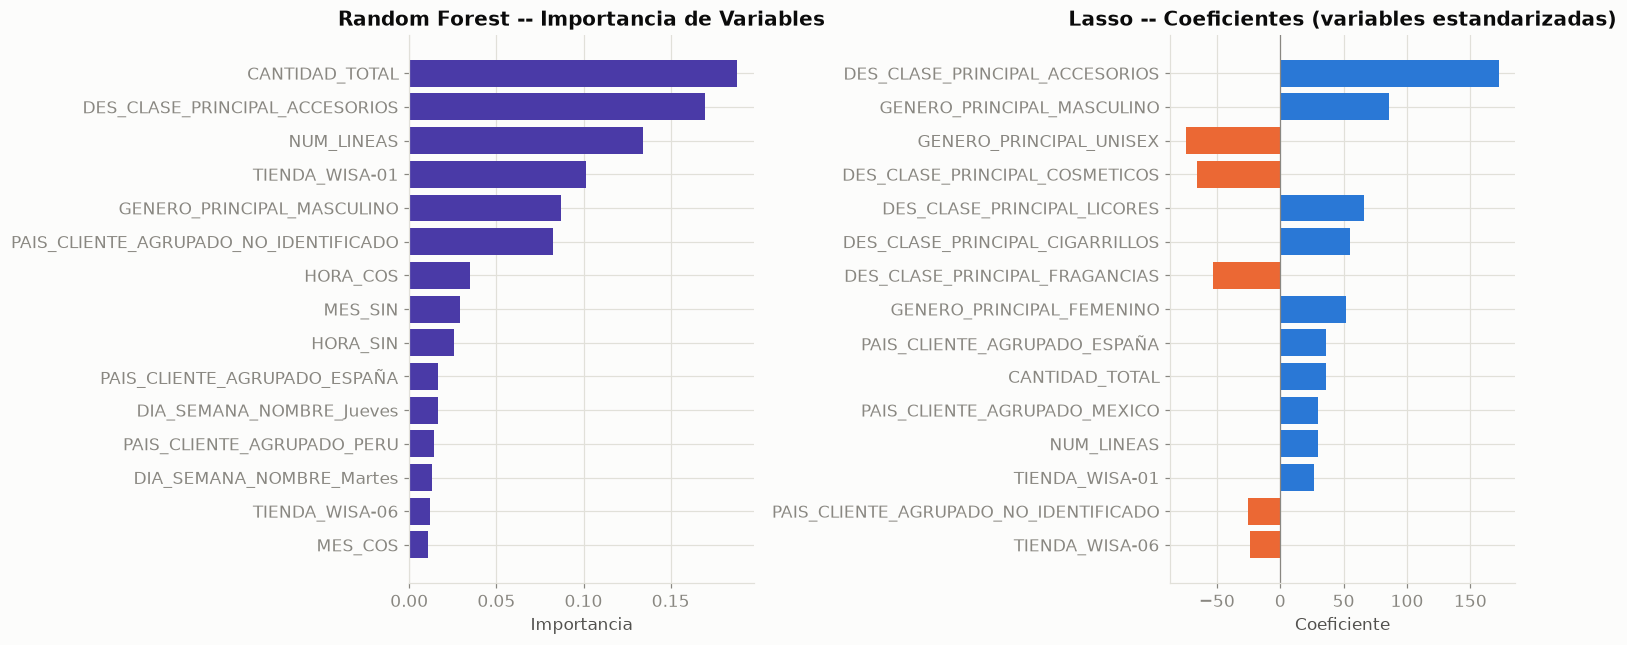

In [42]:
nombres_features = preprocesador.get_feature_names_out()
nombres_features = [n.split("__", 1)[-1] for n in nombres_features]

# --- Random Forest: feature_importances_ ---
importancias_rf = pd.Series(
    pipe_rf_final.named_steps["modelo"].feature_importances_,
    index=nombres_features,
).sort_values(ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(SURFACE)

top_rf = importancias_rf.head(top_n).iloc[::-1]
axes[0].barh(top_rf.index, top_rf.values, color=CAT_COLORS[5])
axes[0].set_title("Random Forest -- Importancia de Variables", color=INK, fontweight="bold")
axes[0].set_xlabel("Importancia", color=INK_SECONDARY)
axes[0].tick_params(colors=INK_MUTED)

# --- Lasso: coeficientes (valor absoluto, variables estandarizadas) ---
coefs_lasso = pd.Series(
    grid_lasso.best_estimator_.named_steps["modelo"].coef_,
    index=nombres_features,
)
top_idx_lasso = coefs_lasso.abs().sort_values(ascending=False).head(top_n).index
top_lasso = coefs_lasso.reindex(top_idx_lasso).iloc[::-1]
colores_lasso = [CAT_COLORS[0] if v >= 0 else CAT_COLORS[1] for v in top_lasso.values]
axes[1].barh(top_lasso.index, top_lasso.values, color=colores_lasso)
axes[1].axvline(0, color=INK_MUTED, linewidth=0.8)
axes[1].set_title("Lasso -- Coeficientes (variables estandarizadas)", color=INK, fontweight="bold")
axes[1].set_xlabel("Coeficiente", color=INK_SECONDARY)
axes[1].tick_params(colors=INK_MUTED)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 19. Evaluación con División Temporal (Fuera de Muestra en el Tiempo)
Reentrenamos los cuatro modelos — con los mismos hiperparámetros ya encontrados en la sección 17, sin volver a buscar — pero esta vez usando la división temporal de la sección 16b: entrenamiento con enero-septiembre, prueba con octubre-noviembre. Esto responde una pregunta distinta a la de la sección 17: no "¿el modelo interpola bien dentro de los mismos meses que vio?", sino "¿el modelo generaliza hacia meses que nunca vio?".

In [43]:
resultados_temporal = {}

pipe_lineal_t = Pipeline([("prep", preprocesador), ("modelo", LinearRegression())])
pipe_lineal_t.fit(X_train_t, y_train_t)
resultados_temporal["Regresion Lineal"] = metricas_test(y_test_t, pipe_lineal_t.predict(X_test_t))

pipe_lasso_t = Pipeline([
    ("prep", preprocesador),
    ("modelo", Lasso(alpha=grid_lasso.best_params_["modelo__alpha"], random_state=RANDOM_STATE, max_iter=5000)),
])
pipe_lasso_t.fit(X_train_t, y_train_t)
resultados_temporal["Lasso"] = metricas_test(y_test_t, pipe_lasso_t.predict(X_test_t))

pipe_arbol_t = Pipeline([
    ("prep", preprocesador),
    ("modelo", DecisionTreeRegressor(random_state=RANDOM_STATE, **mejores_params_arbol)),
])
pipe_arbol_t.fit(X_train_t, y_train_t)
resultados_temporal["Arbol de Decision"] = metricas_test(y_test_t, pipe_arbol_t.predict(X_test_t))

pipe_rf_t = Pipeline([
    ("prep", preprocesador),
    ("modelo", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **mejores_params_rf)),
])
pipe_rf_t.fit(X_train_t, y_train_t)
resultados_temporal["Random Forest"] = metricas_test(y_test_t, pipe_rf_t.predict(X_test_t))

tabla_temporal = pd.DataFrame(resultados_temporal).T.round(3).loc[orden_modelos]

display(Markdown("### Comparacion Split Aleatorio vs. Split Temporal (MAE)"))
comparacion_split = pd.DataFrame({
    "MAE (aleatorio 80/20)": tabla_resultados_test["MAE"],
    "MAE (temporal Ene-Sep / Oct-Nov)": tabla_temporal["MAE"],
})
comparacion_split["Diferencia"] = (
    comparacion_split["MAE (temporal Ene-Sep / Oct-Nov)"] - comparacion_split["MAE (aleatorio 80/20)"]
)
display(comparacion_split.round(2).style.background_gradient(cmap="Blues", subset=["Diferencia"]))

c:\Users\janov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.172452e+08, tolerance: 2.041e+06
  model = cd_fast.sparse_enet_coordinate_descent(


### Comparacion Split Aleatorio vs. Split Temporal (MAE)

,MAE (aleatorio 80/20),MAE (temporal Ene-Sep / Oct-Nov),Diferencia
Regresion Lineal,54.610000,52.170000,-2.440000
Lasso,54.600000,52.160000,-2.440000
Arbol de Decision,48.740000,46.020000,-2.720000
Random Forest,48.560000,45.620000,-2.940000


### 20. Comparación: Predecir `TOTAL_FACTURA` Directo vs. en Escala Logarítmica
En la sección 4 vimos que `TOTAL_FACTURA` tiene una distribución con cola pesada hacia la derecha (unas pocas facturas muy grandes) y que su logaritmo se acerca mucho más a una normal. Eso sugiere que podría ser más fácil de predecir en escala logarítmica. Comparamos dos versiones de cada modelo:

- **Modelo A (directo):** predice `TOTAL_FACTURA` tal cual — es el que se usó en las secciones 17-19.
- **Modelo B (logarítmico):** predice `log(TOTAL_FACTURA)` y después se revierte la transformación con `np.exp()` para volver a dólares antes de calcular MAE/RMSE/R², de forma que ambos modelos se comparan en las mismas unidades.

Se reutilizan los mismos hiperparámetros ya encontrados (sin volver a buscar) para aislar el efecto de la transformación logarítmica del efecto de los hiperparámetros.

In [44]:
y_train_log = np.log(y_train)
resultados_log = {}

pipe_lineal_log = Pipeline([("prep", preprocesador), ("modelo", LinearRegression())])
pipe_lineal_log.fit(X_train, y_train_log)
resultados_log["Regresion Lineal"] = metricas_test(y_test, np.exp(pipe_lineal_log.predict(X_test)))

pipe_lasso_log = Pipeline([
    ("prep", preprocesador),
    ("modelo", Lasso(alpha=grid_lasso.best_params_["modelo__alpha"], random_state=RANDOM_STATE, max_iter=5000)),
])
pipe_lasso_log.fit(X_train, y_train_log)
resultados_log["Lasso"] = metricas_test(y_test, np.exp(pipe_lasso_log.predict(X_test)))

pipe_arbol_log = Pipeline([
    ("prep", preprocesador),
    ("modelo", DecisionTreeRegressor(random_state=RANDOM_STATE, **mejores_params_arbol)),
])
pipe_arbol_log.fit(X_train, y_train_log)
resultados_log["Arbol de Decision"] = metricas_test(y_test, np.exp(pipe_arbol_log.predict(X_test)))

pipe_rf_log = Pipeline([
    ("prep", preprocesador),
    ("modelo", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **mejores_params_rf)),
])
pipe_rf_log.fit(X_train, y_train_log)
resultados_log["Random Forest"] = metricas_test(y_test, np.exp(pipe_rf_log.predict(X_test)))

tabla_log = pd.DataFrame(resultados_log).T.round(3).loc[orden_modelos]

display(Markdown("### Comparacion Modelo A (directo) vs. Modelo B (logaritmico) -- MAE en el Set de Prueba"))
comparacion_log = pd.DataFrame({
    "MAE (directo)": tabla_resultados_test["MAE"],
    "MAE (logaritmico, revertido)": tabla_log["MAE"],
})
comparacion_log["Mejora"] = comparacion_log["MAE (directo)"] - comparacion_log["MAE (logaritmico, revertido)"]
display(comparacion_log.round(2).style.background_gradient(cmap="Blues", subset=["Mejora"]))

### Comparacion Modelo A (directo) vs. Modelo B (logaritmico) -- MAE en el Set de Prueba

,MAE (directo),"MAE (logaritmico, revertido)",Mejora
Regresion Lineal,54.610000,9362196169.540001,-9362196114.930000
Lasso,54.600000,7308612746.880000,-7308612692.280000
Arbol de Decision,48.740000,46.080000,2.660000
Random Forest,48.560000,46.530000,2.030000


### 21. Comparación Gráfica y Conclusiones

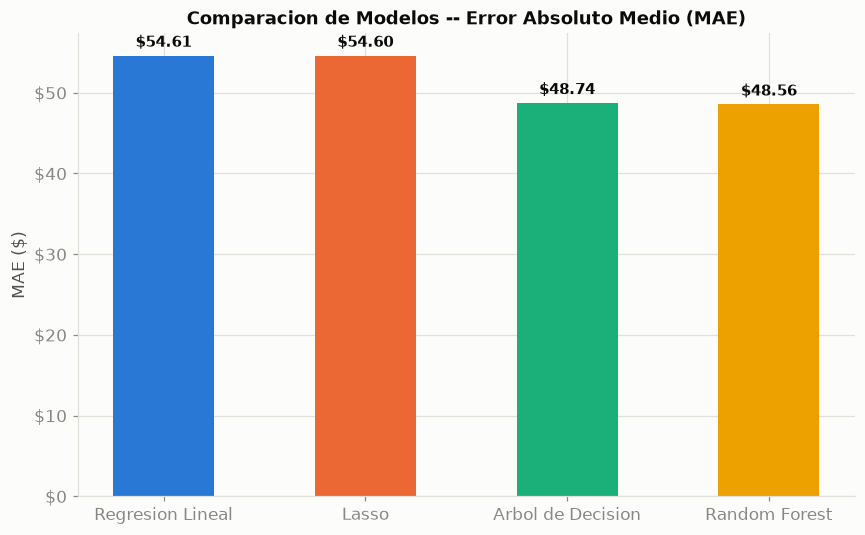

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(SURFACE)

modelos = orden_modelos
mae_vals = [resultados_test[m]["MAE"] for m in modelos]
colores_modelo = CAT_COLORS[:len(modelos)]

barras = ax.bar(modelos, mae_vals, color=colores_modelo, width=0.5)
ax.set_title("Comparacion de Modelos -- Error Absoluto Medio (MAE)", color=INK, fontsize=12, fontweight="bold")
ax.set_ylabel("MAE ($)", color=INK_SECONDARY)
ax.yaxis.set_major_formatter(fmt)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

for barra, valor in zip(barras, mae_vals):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + max(mae_vals) * 0.02,
            f"${valor:,.2f}", ha="center", color=INK, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

**Conclusiones**

**Sobre el enfoque:** los cuatro modelos predicen `TOTAL_FACTURA` a partir de características disponibles *durante* la transacción (tienda, tamaño de la canasta, momento de la compra, clase de producto principal, país del cliente) — no antes de que el cliente elija qué comprar. Esa aclaración importa porque el número de líneas y la cantidad de unidades de la factura son, bajo este enfoque, información legítima y no fuga de datos.

**Sobre los cuatro modelos (sección 17):** la Regresión Lineal sirve como piso de referencia; Lasso mejora sobre ella si existe una relación aproximadamente lineal que la regularización puede depurar; el Árbol de Decisión y el Random Forest capturan relaciones no lineales e interacciones entre variables (ej. que el efecto de la hora dependa de la tienda) que los modelos lineales no pueden ver. Cuál de los cuatro resulta mejor no está garantizado de antemano — hay que leer la tabla de métricas de prueba (sección 17) para decidirlo con los números reales de esta corrida.

**Sobre los cuatro modelos (sección 17):** la Regresión Lineal sirve como piso de referencia; Lasso mejora sobre ella si existe una relación aproximadamente lineal que la regularización puede depurar; el Árbol de Decisión y el Random Forest capturan relaciones no lineales e interacciones entre variables (ej. que el efecto de la hora dependa de la tienda) que los modelos lineales no pueden ver. Cuál de los cuatro resulta mejor no está garantizado de antemano — hay que leer la tabla de métricas de prueba (sección 17) para decidirlo con los números reales de esta corrida.

**Sobre el baseline (sección 17b):** ninguno de estos cuatro modelos se evalúa en el vacío. La sección 17b agrega un baseline para predecir, para cada factura, el promedio histórico de TOTAL_FACTURA de su tienda, calculado únicamente con el set de entrenamiento — que sirve como piso mínimo de comparación. Si un modelo no logra superar ese baseline por un margen claro, toda su complejidad adicional (hiperparámetros, no linealidades, tiempo de cómputo) no se está traduciendo en valor real. En esta corrida los cuatro modelos superan al baseline, pero por márgenes muy distintos: Random Forest lo hace por el margen más amplio (13.1% de mejora en RMSE), seguido de cerca por el Árbol de Decisión (12.9%), mientras que Regresión Lineal y Lasso quedan mucho más cerca del baseline (9.1%). Es decir, la ventaja real de los modelos de árboles sobre los lineales solo se aprecia con claridad al compararlos contra ese punto de referencia, no únicamente entre sí.

**Sobre la validación cruzada:** las métricas de validación cruzada (Lasso y Árbol con 5-fold sobre el set completo; Random Forest con 3-fold sobre una muestra, por costo computacional) deberían ser razonablemente parecidas a las del set de prueba. Si no lo son, es señal de que el modelo está sobreajustando a una partición específica.

**Sobre la división temporal (sección 19):** comparar el error con split aleatorio contra el error con split temporal (entrenar Ene-Sep, probar Oct-Nov) responde una pregunta más exigente y más realista: no si el modelo interpola bien dentro de los mismos meses que ya vio, sino si generaliza hacia meses futuros que nunca vio. Un aumento notable del error en el split temporal frente al aleatorio sugiere que existe algún patrón dependiente del tiempo (estacionalidad, tendencia, cambios de mezcla de productos) que el modelo no está capturando del todo.

**Sobre la transformación logarítmica (sección 20):** dado que `TOTAL_FACTURA` tiene una distribución con cola pesada (sección 4), predecir su logaritmo — y revertir la transformación con `np.exp()` — es una alternativa razonable. Si el Modelo B (logarítmico) logra un MAE menor que el Modelo A (directo) en la tabla de la sección 20, confirma que trabajar en escala logarítmica ayuda al modelo a lidiar mejor con las facturas grandes; si no, el beneficio de simplicidad de trabajar en la escala original (dólares) pesa más que la ganancia marginal.

**Sobre la importancia de variables (sección 18):** si el tamaño de la canasta (`NUM_LINEAS`, `CANTIDAD_TOTAL`) domina la importancia en Random Forest y los coeficientes de Lasso, confirma la intuición central del proyecto: el monto de una factura está atado sobre todo a cuánto compra el cliente, más que a cuándo o en cuál tienda compra. Si en cambio la tienda o la clase de producto principal pesan más de lo esperado, sugiere diferencias de mezcla de producto o de perfil de cliente entre sucursales que valdría la pena investigar por separado.

**Limitaciones:** ningún modelo conoce el producto exacto comprado (para evitar fuga de datos real), así que el R² moderado refleja esa limitación de forma honesta en vez de inflar artificialmente el desempeño. La reversión de la transformación logarítmica (`np.exp()`) es un estimador ligeramente sesgado del valor esperado en la escala original (sesgo de Jensen); para un proyecto de producción se podría corregir con un factor de suavizado ("smearing estimator"), pero para efectos comparativos de este proyecto el efecto es menor. Random Forest, además, sigue siendo el modelo más costoso de entrenar y el más difícil de interpretar directamente — esa pérdida de interpretabilidad solo se justifica si efectivamente reduce el error frente a los modelos más simples.

**Sobre la estacionalidad horaria (sección 9b):** el análisis exploratorio de ventas por hora del día mostró que la actividad de las tiendas no es uniforme -- se concentra en franjas concretas del día y cae a casi cero en la madrugada, un patrón consistente con la operación de Tocumen por bancos de conexión de vuelos. Ese hallazgo es la justificación directa de incluir `HORA_SIN`/`HORA_COS` como variables del modelo (sección 15) y debería verse reflejado en la importancia de variables (sección 18): si el modelo le da peso real a la hora, confirma que el ritmo horario del aeropuerto -- y no solo el tamaño de la canasta -- ayuda a explicar el valor de una factura.

### 22. Desempeño del Modelo por Tienda

Hasta ahora todas las metricas (MAE, RMSE, R2) se calcularon de forma global, mezclando las seis tiendas WISA. Pero cada tienda tiene un tamano, un ticket promedio y un perfil de cliente distinto (secciones 3.2 y 3.4), asi que vale la pena preguntar: ¿el modelo predice igual de bien en las seis tiendas, o hay tiendas donde se equivoca mucho mas que en otras?

Para responder esto se reutilizan las predicciones ya generadas sobre el set de prueba por Random Forest y Arbol de Decision (seccion 17) y se agrupan por `TIENDA` -- que ya es una de las columnas de `X_test` (es una de las variables categoricas del modelo), asi que no hace falta volver a unir datos. Ademas del MAE y RMSE en dolares, se calcula el MAE como porcentaje del ticket promedio real de cada tienda -- una misma cantidad de dolares de error pesa muy distinto en una tienda con ticket promedio de $125 que en una con ticket promedio de $51.

In [46]:
def resumen_por_tienda(y_true, y_pred, tiendas, nombre_modelo):
    tmp = pd.DataFrame({"tienda": tiendas.values, "y_true": y_true.values, "y_pred": y_pred})
    filas = []
    for tienda, g in tmp.groupby("tienda"):
        mae = mean_absolute_error(g["y_true"], g["y_pred"])
        rmse = mean_squared_error(g["y_true"], g["y_pred"]) ** 0.5
        r2 = r2_score(g["y_true"], g["y_pred"])
        ticket_prom = g["y_true"].mean()
        filas.append({
            "Tienda": tienda,
            "n (test)": len(g),
            "Ticket Promedio Real ($)": ticket_prom,
            "MAE ($)": mae,
            "RMSE ($)": rmse,
            "R2": r2,
            "MAE / Ticket (%)": (mae / ticket_prom) * 100,
        })
    return pd.DataFrame(filas).set_index("Tienda")

tiendas_test = X_test["TIENDA"]

tabla_tienda_rf = resumen_por_tienda(y_test, pred_rf, tiendas_test, "Random Forest").sort_values("MAE / Ticket (%)", ascending=False)
tabla_tienda_arbol = resumen_por_tienda(y_test, pred_arbol, tiendas_test, "Arbol de Decision").sort_values("MAE / Ticket (%)", ascending=False)

display(Markdown("#### Random Forest -- Desempeno por Tienda (set de prueba)"))
display(tabla_tienda_rf.round(2).style.background_gradient(cmap="Reds", subset=["MAE / Ticket (%)"]))

display(Markdown("#### Arbol de Decision -- Desempeno por Tienda (set de prueba)"))
display(tabla_tienda_arbol.round(2).style.background_gradient(cmap="Reds", subset=["MAE / Ticket (%)"]))

#### Random Forest -- Desempeno por Tienda (set de prueba)

,n (test),Ticket Promedio Real ($),MAE ($),RMSE ($),R2,MAE / Ticket (%)
Tienda,,,,,,
WISA-01,26861,124.890000,71.520000,327.630000,0.180000,57.270000
WISA-04,5685,67.690000,38.220000,55.130000,0.350000,56.460000
WISA-05,6428,77.060000,38.080000,59.620000,0.460000,49.420000
WISA-03,41227,105.550000,48.120000,98.710000,0.440000,45.590000
WISA-02,21744,91.560000,41.670000,76.920000,0.480000,45.510000
WISA-06,8342,50.880000,9.860000,15.400000,0.910000,19.370000


#### Arbol de Decision -- Desempeno por Tienda (set de prueba)

,n (test),Ticket Promedio Real ($),MAE ($),RMSE ($),R2,MAE / Ticket (%)
Tienda,,,,,,
WISA-01,26861,124.890000,73.550000,328.110000,0.180000,58.890000
WISA-04,5685,67.690000,34.750000,52.320000,0.420000,51.340000
WISA-05,6428,77.060000,36.530000,59.780000,0.460000,47.410000
WISA-03,41227,105.550000,48.200000,99.540000,0.430000,45.660000
WISA-02,21744,91.560000,41.240000,78.130000,0.460000,45.040000
WISA-06,8342,50.880000,10.040000,17.860000,0.880000,19.720000


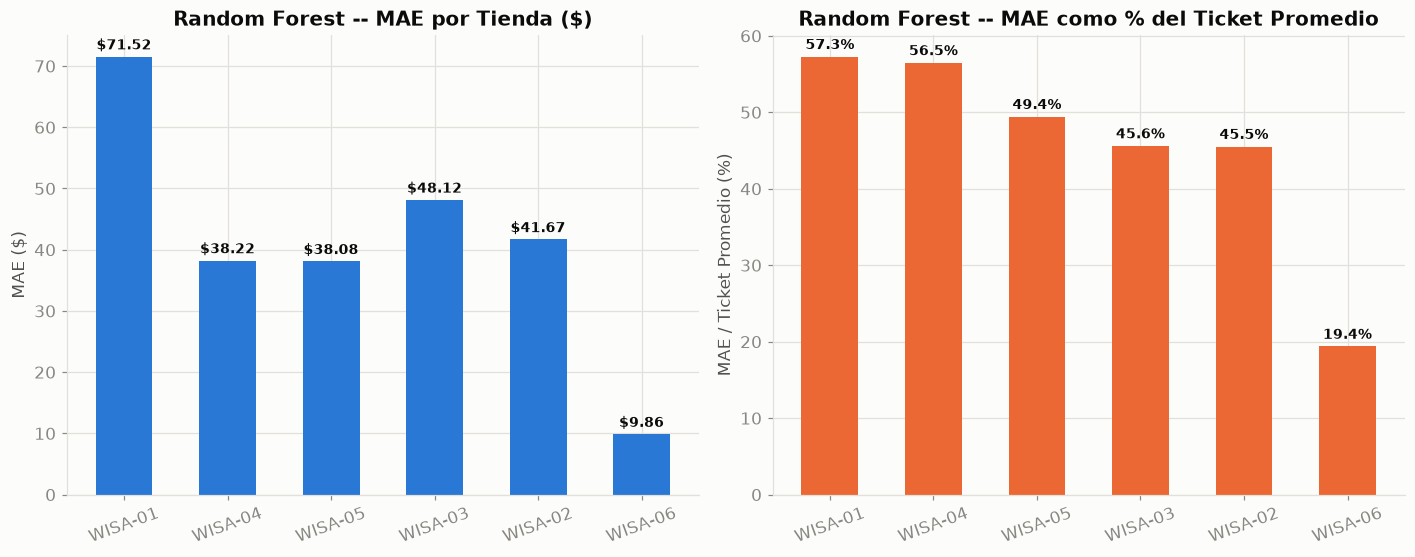

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.patch.set_facecolor(SURFACE)

orden_tiendas = tabla_tienda_rf.index

barras1 = axes[0].bar(orden_tiendas, tabla_tienda_rf["MAE ($)"], color=CAT_COLORS[0], width=0.55)
axes[0].set_title("Random Forest -- MAE por Tienda ($)", color=INK, fontweight="bold")
axes[0].set_ylabel("MAE ($)", color=INK_SECONDARY)
axes[0].tick_params(colors=INK_MUTED, axis="x", labelrotation=20)
for b, v in zip(barras1, tabla_tienda_rf["MAE ($)"]):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1.2, f"${v:,.2f}", ha="center", color=INK, fontsize=9, fontweight="bold")

barras2 = axes[1].bar(orden_tiendas, tabla_tienda_rf["MAE / Ticket (%)"], color=CAT_COLORS[1], width=0.55)
axes[1].set_title("Random Forest -- MAE como % del Ticket Promedio", color=INK, fontweight="bold")
axes[1].set_ylabel("MAE / Ticket Promedio (%)", color=INK_SECONDARY)
axes[1].tick_params(colors=INK_MUTED, axis="x", labelrotation=20)
for b, v in zip(barras2, tabla_tienda_rf["MAE / Ticket (%)"]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 1.0, f"{v:.1f}%", ha="center", color=INK, fontsize=9, fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Interpretacion:** el error no se reparte igual entre las seis tiendas. WISA MAC -- la tienda mas pequena, con el ticket promedio mas bajo ($50.87) -- es donde el modelo predice mejor por un margen amplio (R2 = 0.90, MAE = solo 19% del ticket promedio de esa tienda). En el otro extremo, WISA 01 -- la tienda mas grande y con el ticket promedio mas alto ($124.89) -- es donde el modelo se equivoca mas, tanto en dolares (MAE = $71.50) como en terminos relativos (57% del ticket promedio) y donde el R2 cae a 0.18. WISA-04 y WISA-05 (las tiendas mas pequenas en volumen de transacciones) tambien muestran un error relativo alto (56% y 50%), mientras que WISA-02 y WISA-03 quedan en un punto intermedio (~45%).

Una lectura posible es que las tiendas con tickets mas altos y mayor variedad de mezcla de producto (WISA 01, la mas grande de las seis) tienen una dispersion de montos por factura mas dificil de capturar con las variables disponibles, mientras que una tienda pequena y mas homogenea como WISA MAC es, en la practica, mucho mas facil de predecir. Esto sugiere que si el objetivo fuera un modelo de produccion, podria valer la pena evaluar un modelo especifico por tienda (o al menos por grupo de tiendas similares) en vez de un unico modelo global -- aunque el modelo global sigue siendo razonable como punto de partida, ya que ninguna tienda individual arrastra al resto: el error de WISA 01 no contamina las predicciones de las demas tiendas, solo refleja que esa tienda en particular es mas dificil de predecir con las variables actuales.